# 历年国赛 / 美赛中的预测类问题｜核心突破实战课件

> 4 道真实往年赛题的教学化求解：题目是什么 → 完整建模流程是什么 → 为什么这样选模型 → 代码怎么跑 → 指标怎么读 → 结论怎么写。

## 先说明这份课件的边界

这不是历年获奖论文的复制，也不是声称给出赛题唯一答案。数学建模竞赛本来就没有唯一标准模型。本课件做的是：

1. 选取真实往年赛题；
2. 保留题目的核心机制；
3. 为了让初学者能独立运行，使用明确写出的**教学参数或简化数据**；
4. 给出一套逻辑完整、能运行、能解释、能继续扩展的基线方案。

如果正式参赛，必须进一步使用官方附件、估计参数、做严格验证，并按题目要求完成论文。

## 本课选取的 4 道题

|年份与赛事|题目|主要方法|本课回答的核心问题|
|---|---|---|---|
|2021 全国大学生数学建模竞赛 B 题|乙醇偶合制备 C4 烯烃|响应面回归、交叉验证、约束寻优|怎样用少量实验预测收率，并找出更好的工艺条件？|
|2023 MCM Problem C|Predicting Wordle Results|时序分解、词特征、区间预测|怎样同时预测上报人数和猜测次数分布？|
|2025 全国大学生数学建模竞赛 C 题|NIPT 的时点选择与胎儿异常判定|相关/回归、分组、风险最优时点|Y 染色体浓度何时达标，检测该安排在哪一周？|
|2024 MCM Problem C|Momentum in Tennis|去发球优势后的动量、转折预测|怎样量化“势头”，并判断它会不会翻转？|

## 学完应该会什么？

- 能从题面判断这是**点预测、区间预测、分类预测还是分布预测**；
- 能写出完整流程：数据审计 → 防泄漏清洗 → 特征工程 → 正确划分 → 模型比较 → 残差诊断 → 接到决策；
- 能解释为什么时序题不能随机打乱交叉验证；
- 能在 RMSE、MAE、MAPE、覆盖率、AUC 之间按题目目标选指标；
- 能先建立一个可解释的基线，再决定要不要上更复杂的模型；
- 能写出假设、局限和“正式参赛还应补什么”。

## 资料来源与题目真实性

- [全国大学生数学建模竞赛历年赛题汇总](https://www.mcm.edu.cn/html_cn/node/a0c1fb5c31d43551f08cd8ad16870444.html)
- [2023 MCM Problem C：Predicting Wordle Results](https://www.contest.comap.com/undergraduate/contests/mcm/contests/2023/problems/)
- [2024 MCM Problem C：Momentum in Tennis](https://www.contest.comap.com/undergraduate/contests/mcm/contests/2024/problems/)
- [2021 国赛 B 题讲评与题面公开资料](https://www.mcm.edu.cn/)
- [2025 国赛 C 题讲评：NIPT 的时点选择与胎儿的异常判定](https://dxs.moe.gov.cn/zx/a/hd_sxjm_sxjmstjp_2025sxjmstjp/251202/2025781.shtml)

本 Notebook 对官方题意做中文概括，不大段复制题面。模型中的演示数据均在对应章节标注，**不能当作官方附件或现实预测**。

# 0. 预测类问题到底是什么？

## 0.1 一句话定义

预测类问题的本质不是“套一个回归公式”，而是：

> 在**信息不完全**的条件下，用已经观测到的变量，对**尚未观测到的量**给出可检验的估计，并把不确定性说清楚，以便后面做决策。

竞赛里它常以这些句式出现：

- “请预测未来 7 天的销量 / 人数 / 价格”；
- “请建立 $Y$ 与 $X_1,X_2,\ldots$ 的关系模型，并检验显著性”；
- “请给出某日期、某单词、某工艺条件下的结果及其区间”；
- “请判断下一次检测是否达标 / 下一分会不会发生势头翻转”。

## 0.2 先分清你在预测什么

|类型|输出长什么样|典型赛题说法|常见模型|
|---|---|---|---|
|回归 / 点预测|一个数 $\hat y$|销量、收率、浓度、人数|线性/多项式、岭回归、随机森林、ARIMA|
|区间预测|$[\hat y_L,\hat y_U]$|给出预测区间、置信区间|分位数回归、残差bootstrap、时序区间|
|分类预测|类别或概率|是否异常、是否完成、是否违约|逻辑回归、随机森林、SVM|
|分布预测|一整条分布|1–6 次猜中的百分比|多项回归、Dirichlet、分箱概率|
|生存 / 首次达标时间|时间 $T$ 或生存曲线|最早达标孕周|生存分析、首次穿越阈值|

**核心突破 1**：题目问的若是“区间”或“分布”，只交一个点估计，分数会明显偏低。

## 0.3 预测问题和其他问题的边界

- 和**机理仿真**不同：微分方程先写机制再算轨迹；预测题常常先有数据，机制是用来约束模型，不是用来替代数据。
- 和**评价决策**不同：评价是给方案打分排序；预测是给未知量赋值。很多赛题是“先预测，再决策”，例如 2023 国赛 C 题蔬菜补货、2025 国赛 C 题 NIPT 时点。
- 和**插值**不同：插值要求曲线穿过已有点；预测要在未见样本上泛化。

## 0.4 竞赛里预测题最容易丢分的 8 个坑

1. **数据泄漏**：用了未来信息、用了由 $y$ 直接算出来的特征、测试集参与了标准化。
2. **乱切数据**：时序题随机 8:2，把“明天”泄漏给“今天”。
3. **没有基线**：一上来 XGBoost，却不和“昨天等于今天”、历史均值、简单线性比。
4. **指标与目标错位**：销量决策看的是绝对误差和库存代价，却只报 $R^2$。
5. **外推不检查**：实验温度只到 400°C，却把最优点报到 480°C。
6. **把相关当因果**：BMI 与达标时间相关，不等于“降低 BMI 就能提前检测”。
7. **忽略单位和口径**：孕周写成 `12w+3d` 却当 12.3；销量混了“千克”和“份”。
8. **不谈不确定性**：给一个精确到小数点后 4 位的点，却没有任何区间。

# 0.5 完整建模流程：从拆题到交论文

下面这套流程适用于绝大多数国赛 C 题和美赛 C 题。后面 4 个案例都会反复走这一遍。

$$
\boxed{拆题 \rightarrow 数据审计 \rightarrow 清洗与防泄漏 \rightarrow 特征工程 \rightarrow 划分策略 \rightarrow 基线 \rightarrow 候选模型 \rightarrow 评价 \rightarrow 诊断 \rightarrow 不确定度 \rightarrow 接到决策 \rightarrow 敏感性}
$$

## 第一步：拆题，先写下“预测合同”

动手前必须能填完这张表。填不完就不要建模。

|合同项|必须写清楚的内容|反例|
|---|---|---|
|预测对象 $y$|精确到口径和单位|“预测销售情况”（太含糊）|
|预测原点|决策发生的时刻|用到了决策日当天晚上才出来的数|
|预测步长|未来 1 天、7 天，还是下一次实验|把长期趋势模型拿去报明天|
|样本粒度|单品-日、孕妇-次、比赛-分|把周数据直接当每日数据|
|可用信息集|决策时真正看得到的变量|用了标签本身或未来天气实况|
|成功标准|误差、覆盖率、排序、还是决策收益|只说“效果较好”|

## 第二步：数据审计（比建模更早）

拿到附件先做“户口普查”，不要先画漂亮曲线。

1. **一张表看什么**：行是谁、列是什么、主键是否唯一、时间是否排序。
2. **缺失**：随机缺失、周末缺失、失败检测缺失，处理方式完全不同。
3. **异常**：3 倍 IQR、物理上下界（浓度不能为负、转化率不能超过 100%）。
4. **重复与冲突**：同一孕妇同一天两次抽血，是重复还是真实多次检测。
5. **口径**：价格含税吗？销量是下单还是出库？孕周是抽血日还是末次月经推算。
6. **分布**：偏态、零膨胀、封顶、季节性、结构性断点。
7. **泄漏线索**：特征名里出现 `未来`、`当日完成后`、`标签衍生`。

建议输出一张“数据质量一览表”：样本量、缺失率、异常率、时间跨度、分组数。审稿人很吃这一张表。

## 第三步：清洗，但必须可复现、可辩护

|问题|推荐做法|不推荐|
|---|---|---|
|少量随机缺失|中位数 / 组内中位数，并加缺失指示变量|随手填 0|
|系统性缺失|单独建模“为何缺失”（如测序失败）|当普通缺失删掉|
|极端值有物理意义|winsorize 或分箱，保留指示|直接全部删除|
|单位混乱|先统一，再进模型|各列自己看着办|
|分类水平稀有|合并为“其他”|给每个罕见类别单独独热|

**核心突破 2**：清洗规则必须只在训练集上学习，再应用到验证/测试集。

## 第四步：特征工程——预测题真正拉开差距的地方

模型可以普通，特征不能随便。按题目类型选武器：

### 回归 / 实验设计题（乙醇、工艺、剂量）

- 主效应：$x_i$
- 平方项：$x_i^2$（温度过高后转化率可能饱和甚至下降）
- 交互项：$x_i x_j$（负载量 × 温度）
- 有界变换：$\mathrm{logit}(y)$、$\log(1+x)$，保证预测不越界

### 时间序列题（销量、Wordle 人数、价格）

- 日历：星期、月份、节假日、开学、比赛日
- 滞后：`lag1`, `lag7`, `lag365`
- 滚动：近 7 日均值 / 标准差
- 趋势：线性时间、分段时间、傅里叶季节项
- **绝不**把 $y_{t+1}$ 的信息放进 $x_t$

### 文本 / 单词题（Wordle）

- 词长、元音数、重复字母、唯一字母数
- 字母频率、常见字母位置
- 与已公开词表的相似度
- 难度代理：起手词命中率、词形稀有度

### 纵向 / 医学题（NIPT）

- 孕周连续化：`12w+3d` → $12 + 3/7$
- BMI、年龄、IVF、抽血次数
- 孕妇层面随机效应（同一人多次检测不独立）
- 阈值特征：尚未达标的次数、距 4% 的差距

### 序列 / 比赛题（网球动量）

- 发球局指示
- 近 $k$ 分胜率、破发点、连续得分
- 去发球优势后的残差
- 盘分、局分、关键分

**特征筛选原则**：先看相关和互信息，再看交叉验证，最后看系数/SHAP。不要把 80 个高度共线的特征全塞进去。

## 第五步：划分策略——这是“对”和“看起来对”的分水岭

|数据形态|正确划分|错误划分|
|---|---|---|
|普通截面回归|随机 K 折，或按实验批次分组折|把同一组实验拆进训练和测试却不声明|
|时间序列|时间切分 / `TimeSeriesSplit`|随机打乱|
|同一对象多次观测|按孕妇 / 企业 / 球员分组折|把同一个人的两次检测分到两边|
|分类不平衡|分层抽样|不管正负比例|

经验比例：截面 70/15/15；时序用“最后一段当测试”，前面再做滚动验证。

## 第六步：先基线，后复杂模型

竞赛里一个稳的顺序：

1. **朴素基线**：历史均值、昨天等于今天、季节均值、经验阈值。
2. **可解释模型**：线性回归、逻辑回归、Ridge、分段回归。
3. **结构模型**：多项式响应面、ARIMA / Holt-Winters、广义线性模型。
4. **灵活模型**：随机森林、梯度提升、小规模神经网络。
5. **只有当 4 明显优于 2，且能解释多出来的收益时，才把它当主模型。**

**核心突破 3**：能讲清机制的次优模型，往往比讲不清的最优模型更能拿奖。

## 第七步：评价指标——先匹配题目，再报数字

### 连续预测

|指标|公式直觉|什么时候用|弱点|
|---|---|---|---|
|RMSE|大误差会被平方放大|工艺、浓度、赛题强调精度|被极端值绑架|
|MAE|平均绝对偏差|销量、人数、解释给评委听|对大错不够敏感|
|MAPE|相对误差百分比|跨量级比较|真实值接近 0 时爆炸|
|sMAPE|对称相对误差|有零或接近零|解释稍绕|
|$R^2$|解释了多少方差|关系建模、显著性配套|高 $R^2$ 不等于预测好|
|覆盖率 / 区间宽度|区间是否罩住真值|题目要预测区间|可以靠把区间拉得很宽作弊，所以要同时看宽度|

### 分类预测

|指标|适用|注意|
|---|---|---|
|准确率|类别均衡|异常检测里会虚高|
|精确率 / 召回率 / F1|不平衡、漏检代价高|必须说以哪一类为正类|
|AUC|排序能力|阈值还没选时很好用|
|校准（可靠性）|要把概率当风险用|AUC 高也可能概率不准|
|代价敏感准确率|漏检 ≠ 误报|医学、信贷必须自定义代价|

### 排序 / 分布

- 分布：KL 散度、Wasserstein、分箱 MAE
- 排序：Spearman、NDCG、Top-K 命中

**核心突破 4**：指标要能回到题目语言。例如 NIPT 应同时报“达标率”和“平均发现孕周”，而不是只报回归 $R^2$。

## 第八步：诊断，证明模型没有在胡说

至少看这 5 张图 / 5 个数：

1. 预测 vs 真实散点，应沿 $y=x$；
2. 残差 vs 拟合值，不应有喇叭口或弯曲；
3. 残差 QQ 图，判断是否需要变换；
4. 时序题：残差 ACF，看有没有没吃干净的季节；
5. 分组误差：按 BMI、按单词难度、按发球方分别看，避免“平均上还行、关键组很差”。

再做三个常识检查：转化率是否越界、人数是否为负、概率是否在 $[0,1]$。

## 第九步：把预测接到决策

预测本身通常不是终点。

- 乙醇：收率预测 → 工艺寻优；
- Wordle：人数区间 → 服务器与内容运营；
- NIPT：浓度曲线 → 最佳检测时点；
- 网球：动量 → 教练临场调整。

论文里要有一句：

> 若预测偏差 $\delta$，决策会怎样变？

这就是敏感性和价值评估。

## 第十步：正式参赛最低验证清单

- [ ] 训练信息没有泄漏到测试
- [ ] 至少 2 个模型 + 1 个朴素基线
- [ ] 指标与题目一致，且训练集/验证集都报告
- [ ] 残差和分组误差已检查
- [ ] 给出区间或情景，而不是单点神话
- [ ] 外推区域单独声明
- [ ] 代码设了随机种子，表格由代码生成

## 0.6 环境准备

运行下面单元。后面的表格和图片均由代码真实计算，不是手工贴图。

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, KFold, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans

try:
    import statsmodels.api as sm
    HAS_SM = True
except Exception:
    HAS_SM = False

try:
    from IPython.display import display
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    display = print

SEED = 2026
rng = np.random.default_rng(SEED)
COLORS = {
    'navy': '#16324F', 'blue': '#2878B5', 'cyan': '#2A9D8F',
    'yellow': '#E9C46A', 'orange': '#F4A261', 'red': '#E76F51',
    'purple': '#7B6DCC', 'gray': '#7A8793', 'green': '#43AA8B'
}

_installed = {f.name for f in font_manager.fontManager.ttflist}
for _name in ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Noto Sans SC', 'Arial Unicode MS']:
    if _name in _installed:
        plt.rcParams['font.sans-serif'] = [_name] + list(plt.rcParams.get('font.sans-serif', []))
        break
plt.rcParams.update({
    'figure.figsize': (10, 5.4), 'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.20,
    'axes.unicode_minus': False
})


def show_result(table=None, fig=None):
    if globals().get('BUILDING_NOTEBOOK', False):
        return
    if table is not None:
        display(table)
    if fig is not None:
        plt.show()


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > eps
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(np.mean(2.0 * np.abs(y_true - y_pred) / denom))


def regression_report(y_true, y_pred, name='model'):
    return {
        '模型': name,
        'RMSE': rmse(y_true, y_pred),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'MAPE': mape(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'R2': float(r2_score(y_true, y_pred)),
    }


def minmax_norm(x, benefit=True):
    x = np.asarray(x, dtype=float)
    lo, hi = np.nanmin(x), np.nanmax(x)
    if hi - lo < 1e-12:
        return np.ones_like(x) * 0.5
    z = (x - lo) / (hi - lo)
    return z if benefit else 1.0 - z


print('环境就绪：NumPy', np.__version__, '| Pandas', pd.__version__,
      '| statsmodels', '是' if HAS_SM else '否')

环境就绪：NumPy 2.5.1 | Pandas 3.0.5 | statsmodels 是


# 案例一｜2021 国赛 B 题：乙醇偶合制备 C4 烯烃

> 这一节把学生当成第一次做实验数据题。先把题面翻译成人话，再一问一问告诉你论文里该写什么、公式里每个字母是什么意思。后面的代码只是把这里写出来的步骤算一遍。

## 1.1 先用大白话读懂题目

工厂想用乙醇（一种常见酒精）在催化剂上反应，做成 C4 烯烃（四个碳的烯烃，化工原料）。实验室会改四样东西：

1. **Co 负载量**：钴涂在载体上有多“浓”，单位是重量百分比 $\mathrm{wt}\%$。负载太低，催化位点不够；太高，可能聚团，选择性变差。
2. **$\mathrm{Co/SiO_2}$ 和 HAP 的装料比**：两种固体催化剂按多重放进管子。HAP 是羟基磷灰石，一种载体。
3. **乙醇流量 / 浓度**：单位时间送进去多少乙醇。送太快，来不及反应，转化率可能下降。
4. **反应温度 $T$**：单位是摄氏度 $^\circ\mathrm{C}$。温度升高通常反应更快，但太高可能把产物“烧掉”或让选择性变差。

每次实验，仪器会告诉你两个百分数：

- **乙醇转化率 $y_1$**：进去的乙醇有多大比例被反应掉了。$y_1=0.6$ 表示 60% 的乙醇转化了。它必须落在 $[0,1]$。
- **C4 烯烃选择性 $y_2$**：转化掉的乙醇里，有多大比例变成了我们想要的 C4 烯烃，而不是乙烯、乙醛那些副产物。同样在 $[0,1]$。

题目自己定义了真正关心的综合指标：

$$
y \;=\; y_1 \times y_2.
$$

- $y$ 叫做 **C4 烯烃收率**。
- 为什么是相乘：只有“转化了”并且“转化成了目标产物”的那一部分，才是真正收到的目标产物。转化率很高但选择性很低，收率照样低。

题目不是让你背这个定义，而是让你：**用有限次实验，学会预测任意工艺条件下的收率，再找出更好的工艺。**

## 1.2 官方四问，翻译成你会做的作业

**第 1 问：每种催化剂组合下，转化率、选择性怎样随温度变？350°C 那组随时间稳不稳？**

人话：先不要把所有实验混在一起。固定一种催化剂配方，只让温度变，画 $y_1$–$T$、$y_2$–$T$ 两条曲线。另外，附件 2 在 350°C 连续测了好几个时刻，看收率是很快稳定，还是一直漂。

论文里这一问写：**描述 + 单因子拟合**，还不是最终优化。

**第 2 问：催化剂组合和温度，对转化率、选择性的影响显不显著？有没有交互？**

人话：“显著”不是口头禅，是统计检验。你要回答：温度升高，转化率是不是真的变，还是噪声在跳？负载量和温度会不会“搭在一起起作用”（交互）——比如高负载只在高温才有害。

**第 3 问：怎样选组合和温度，让收率尽量高？如果温度必须低于 350°C 呢？**

人话：这是预测之后的决策。先有 $\hat y(x)$，再在允许的格子里找最大的那个 $x$。加了 $T\le 350$ 后，最优点往往会变。

**第 4 问：还能补 5 次实验，补在哪里？**

人话：不要在已经测得很密的地方再测。去“预测收率高、但模型自己也不确定”的格子补点。

## 1.3 教学数据说明（必读，避免误用）

官方附件是真实实验表。本课为了能脱离附件独立运行，按同样的四个因子生成了 21 条**教学数据**。趋势被设计成：转化率随温度升高并逐渐饱和，选择性在中高温有峰。这些数字**不能**写进正式参赛论文当实验结果。

## 1.4 第 1 问怎么写：先看温度曲线

固定第 $k$ 种催化剂组合，只留下温度 $T$ 和一个响应（转化率或选择性）。最简单的可写模型是二次曲线：

$$
y_1^{(k)}(T) \;=\; a_k + b_k T + c_k T^2 + \varepsilon.
$$

每个字母：

|符号|含义|单位 / 范围|为什么要它|
|---|---|---|---|
|$y_1^{(k)}(T)$|第 $k$ 种配方、温度 $T$ 时的转化率|无量纲，$[0,1]$|题目要的纵坐标|
|$T$|反应温度|$^\circ\mathrm{C}$|第 1 问唯一变化的工艺量|
|$a_k$|截距|与 $y_1$ 相同|温度写成 0 时的形式项，本身不必有物理意义，因为 0°C 不在实验范围|
|$b_k$|一次项系数|$1/^\circ\mathrm{C}$|温度升高时转化率的大致斜率|
|$c_k$|二次项系数|$1/(^\circ\mathrm{C})^2$|$c_k<0$ 表示先升后平或下降，对应“不是越热越好”|
|$\varepsilon$|测量误差|与 $y_1$ 相同|仪器噪声、取样波动，假定均值为 0|

选择性 $y_2^{(k)}(T)$ 用同一形式另估一套系数。

**论文怎么写这一问：**

1. 每个配方一张小表：温度、转化率、选择性、收率。
2. 拟合上面的二次式，报 $R^2$。
3. 看 $c_k$ 的正负：若为负，写“存在适宜温度，不是单调升温”。
4. 对 350°C 时间序列：若收率随时间 $t$ 明显下降，说明催化剂可能失活，后面用稳态平均值时要声明。

## 1.5 第 2 问怎么写：显著性和交互

现在不再固定配方，把四个工艺量一起当作自变量。记

$$
x \;=\; (\ell,\; h,\; c,\; T).
$$

|符号|人话|典型范围|
|---|---|---|
|$\ell$|Co 负载量|0.5～5 $\mathrm{wt}\%$|
|$h$|HAP 装料比（HAP 质量 / 总固体质量，或题面给的质量比）|0.33～0.67|
|$c$|乙醇流量|约 0.9～2.1 mL/min|
|$T$|温度|250～400°C|

对转化率写一个**带交互的线性模型**（选择性同理）：

$$
y_1 \;=\; \beta_0 + \beta_\ell \ell + \beta_h h + \beta_c c + \beta_T T + \beta_{\ell T}\,(\ell\cdot T) + \varepsilon.
$$

|符号|人话|
|---|---|
|$\beta_0$|所有因子取 0 时的形式截距，解释时更常说“在数据中心处的基准转化率”|
|$\beta_\ell$|**只把负载提高 1 个单位、其它不变**时，转化率平均变多少|
|$\beta_h,\beta_c,\beta_T$|同理，各自的主效应|
|$\beta_{\ell T}$|交互：负载的作用会随温度改变。若 $\beta_{\ell T}<0$，高负载在高温更吃亏|
|$\varepsilon$|剩下解释不了的误差|

**怎样叫“显著”：** 对每个系数做 $t$ 检验，原假设 $H_0:\beta_j=0$（这个因子没用）。得到 $p$ 值。竞赛里常把 $p<0.05$ 写成显著，但必须同时报告系数正负和实际大小——$p$ 很小但系数只有 0.001，工程上仍可忽略。

交互也可以用方差分析（ANOVA）表述：把总平方和拆成“温度的贡献 + 负载的贡献 + 二者交叉 + 误差”。交叉项显著，就不能只画“平均温度效应”，必须分组讨论。

## 1.6 第 3 问怎么写：先预测收率，再寻优

收率

$$
y \;=\; y_1 y_2 \;\in\; [0,1].
$$

小样本（二三十条）不要上深度网络。用**二阶响应面**：

$$
\hat y(x) \;=\; \beta_0 + \sum_{j=1}^{4}\beta_j x_j + \sum_{j=1}^{4}\beta_{jj} x_j^2 + \sum_{1\le j<k\le 4}\beta_{jk} x_j x_k.
$$

|符号|人话|
|---|---|
|$\hat y(x)$|模型对工艺 $x$ 预测出来的收率，头上的帽子表示“估计值，不是实验室再测一次”|
|$x_j$|第 $j$ 个工艺因子，顺序一般是 $(\ell,h,c,T)$|
|$\beta_j$|主效应：这个因子单独加一点，收率怎么变|
|$\beta_{jj}$|弯曲：温度平方项为负，就是“中间好、两头差”|
|$\beta_{jk}$|两个因子的搭配效应|

因子量纲差很多（温度是 300，负载是 1），直接回归会病态。岭回归在普通最小二乘上加惩罚：

$$
\hat\beta \;=\; \arg\min_{\beta}\ \underbrace{\lVert y - X\beta\rVert_2^2}_{\text{拟合有多准}} + \alpha\underbrace{\lVert\beta\rVert_2^2}_{\text{系数别太大}}.
$$

|符号|人话|
|---|---|
|$y$|长度为 $n$ 的真实收率向量，$n$ 是实验次数|
|$X$|$n\times p$ 的设计矩阵：每一行是一次实验展开后的 $1,x_j,x_j^2,x_j x_k$|
|$\beta$|所有待估系数排成一列|
|$\lVert\cdot\rVert_2$|欧氏长度，平方后就是平常的误差平方和|
|$\alpha>0$|惩罚强度。$\alpha=0$ 退回普通最小二乘；$\alpha$ 太大，系数被压扁，欠拟合|

怎么证明这个 $\hat y$ 能用？把 $n$ 条实验分成 $K=5$ 折。每次留下 1 折当“没见过的实验”，用另外 4 折训练，再预测留下的那折。折外预测记作 $\hat y_i$。三个常用指标：

$$
\mathrm{RMSE} \;=\; \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2},
\qquad
\mathrm{MAE} \;=\; \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i|,
\qquad
R^2 \;=\; 1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}.
$$

|符号|人话|什么时候看它|
|---|---|---|
|$y_i$|第 $i$ 次实验的真实收率|地面真相|
|$\hat y_i$|模型没见过这次实验时的预测|检查会不会死记硬背|
|$\bar y$|全部真实收率的平均值| $R^2$ 的分母：你至少得比“瞎猜平均值”强|
|RMSE|大错会被平方放大|工艺精度|
|MAE|平均偏了多少，好向评委解释|和收率同一个单位|
|$R^2$|模型解释了多少波动，1 最好，0 等于猜平均值|关系好不好，但高 $R^2$ 不等于外推可靠|

还必须报越界率：$\frac{1}{n}\#\{\hat y_i\notin[0,1]\}$。收率预测成 1.2 或 $-0.1$，模型物理上就不合格。

对照模型至少三个：**均值基线**（永远猜平均值）、**普通线性**、**随机森林**。小样本里随机森林常常只好一点点，论文应选能讲清系数的响应面。

寻优：在实验曾经出现过的水平构成的网格 $\mathcal{X}$ 上穷举

$$
x^\star \;=\; \arg\max_{x\in\mathcal{X}} \hat y(x),
\qquad
x^\star_{350} \;=\; \arg\max_{\substack{x\in\mathcal{X}\\ T\le 350}} \hat y(x).
$$

|符号|人话|
|---|---|
|$\mathcal{X}$|允许的工艺组合集合。本课用离散网格，避免外推到从没做过的极端温度|
|$x^\star$|不限温度时，预测收率最高的工艺|
|$x^\star_{350}$|加了“温度不能超过 350°C”之后的最优点|
|$\arg\max$|“让后面那个式子最大的那个 $x$”|

论文里这两行就是第 3 问的两套答案。要写清：这是**模型预测的最优**，不是又做了一次验证实验。

## 1.7 第 4 问怎么写：5 次补实验

已经测过的点记为集合 $\mathcal{D}$。还没测的格子 $x\notin\mathcal{D}$，用已经比较过的几个模型给出均值 $\mu(x)$ 和分歧（标准差）$\sigma(x)$。期望改进

$$
\mathrm{EI}(x) \;=\; \bigl(\mu(x)-y_{\max}\bigr)\Phi(z) + \sigma(x)\,\phi(z),
\qquad
z \;=\; \frac{\mu(x)-y_{\max}}{\sigma(x)}.
$$

|符号|人话|
|---|---|
|$y_{\max}$|目前已经测到的最高真实收率|
|$\mu(x)$|各模型对这个没测格子的平均预测|
|$\sigma(x)$|各模型预测差多少；差得大说明大家没把握|
|$\Phi,\phi$|标准正态的分布函数和密度，用来把“可能超过当前最好”变成一个分数|
|$\mathrm{EI}(x)$|如果去测 $x$，期望能把纪录提高多少|

取 EI 最大的 5 个 $x$，就是第 4 问的设计。原则一句话：**既要可能更好，又要信息缺口大。** 本课代码先把第 1–3 问的预测和寻优跑通；第 4 问按上面的公式写进论文即可。

In [2]:
def make_ethanol_data(n=21, seed=2026):
    r = np.random.default_rng(seed)
    rows = []
    # 覆盖常见催化剂组合，而不是纯随机撒点
    combos = [
        (0.5, 0.33, 0.9), (0.5, 0.50, 1.4), (1.0, 0.33, 1.4),
        (1.0, 0.50, 1.7), (1.0, 0.67, 0.9), (2.0, 0.33, 1.4),
        (2.0, 0.50, 1.7), (2.0, 0.67, 2.1), (5.0, 0.50, 1.7),
    ]
    temps = [250, 275, 300, 325, 350, 375, 400]
    i = 0
    for load, hap, conc in combos:
        T = temps[i % len(temps)]
        i += 1
        # 机理直觉：温度升高转化率上升并饱和；选择性在 330 附近更好
        conv = 0.18 + 0.55 / (1 + np.exp(-(T - 310) / 22))
        conv += 0.04 * np.log1p(load) + 0.03 * hap + 0.02 * (conc - 1.4)
        conv += 0.015 * (load - 1.5) * (T - 320) / 80
        sele = 0.46 + 0.18 * np.exp(-((T - 335) / 55) ** 2)
        sele += -0.035 * np.clip(load - 1.2, 0, None) + 0.04 * hap
        sele += 0.02 * np.tanh(2.0 - conc)
        conv = np.clip(conv + r.normal(0, 0.025), 0.05, 0.97)
        sele = np.clip(sele + r.normal(0, 0.020), 0.15, 0.85)
        rows.append({
            '实验号': f'E{i:02d}', 'Co负载_wt': load, 'HAP装料比': hap,
            '乙醇流量': conc, '温度C': T,
            '转化率': conv, '选择性': sele, '收率': conv * sele
        })
    # 再补若干重复温度点，便于看温度曲线
    extra_T = [250, 300, 350, 400, 275, 325, 375, 360, 280, 340, 310, 390]
    extra_x = [(1.0, 0.5, 1.4), (2.0, 0.5, 1.7), (1.0, 0.67, 1.7),
               (0.5, 0.33, 0.9), (2.0, 0.33, 1.4), (5.0, 0.5, 2.1),
               (1.0, 0.5, 0.9), (2.0, 0.67, 1.4), (1.0, 0.33, 2.1),
               (0.5, 0.67, 1.4), (2.0, 0.5, 0.9), (1.0, 0.5, 1.7)]
    for k, (T, (load, hap, conc)) in enumerate(zip(extra_T, extra_x), start=i + 1):
        conv = 0.18 + 0.55 / (1 + np.exp(-(T - 310) / 22))
        conv += 0.04 * np.log1p(load) + 0.03 * hap + 0.02 * (conc - 1.4)
        sele = 0.46 + 0.18 * np.exp(-((T - 335) / 55) ** 2)
        sele += -0.035 * np.clip(load - 1.2, 0, None) + 0.04 * hap
        conv = np.clip(conv + r.normal(0, 0.02), 0.05, 0.97)
        sele = np.clip(sele + r.normal(0, 0.018), 0.15, 0.85)
        rows.append({
            '实验号': f'E{k:02d}', 'Co负载_wt': load, 'HAP装料比': hap,
            '乙醇流量': conc, '温度C': T,
            '转化率': conv, '选择性': sele, '收率': conv * sele
        })
    return pd.DataFrame(rows)

eth = make_ethanol_data()
audit = pd.DataFrame({
    '字段': eth.columns,
    '类型': [str(t) for t in eth.dtypes],
    '缺失率': eth.isna().mean().round(3).to_list(),
    '最小': [eth[c].min() if pd.api.types.is_numeric_dtype(eth[c]) else '-' for c in eth.columns],
    '最大': [eth[c].max() if pd.api.types.is_numeric_dtype(eth[c]) else '-' for c in eth.columns],
})
print('教学实验共', len(eth), '条。转化率/选择性已限制在物理区间内。')
show_result(eth.head(8))
show_result(audit)

教学实验共 21 条。转化率/选择性已限制在物理区间内。


,实验号,Co负载_wt,HAP装料比,乙醇流量,温度C,转化率,选择性,收率
0,E01,0.5,0.33,0.9,250,0.223176,0.510541,0.113941
1,E02,0.5,0.50,1.4,275,0.265339,0.573412,0.152148
2,E03,1.0,0.33,1.4,300,0.449013,0.598161,0.268582
3,E04,1.0,0.50,1.7,325,0.585738,0.666050,0.390131
4,E05,1.0,0.67,0.9,350,0.681513,0.665389,0.453471
5,E06,2.0,0.33,1.4,375,0.779765,0.572298,0.446258
6,E07,2.0,0.50,1.7,400,0.791794,0.500651,0.396413
7,E08,2.0,0.67,2.1,250,0.289266,0.461046,0.133365


,字段,类型,缺失率,最小,最大
0,实验号,str,0.0,-,-
1,Co负载_wt,float64,0.0,0.5,5.0
2,HAP装料比,float64,0.0,0.33,0.67
3,乙醇流量,float64,0.0,0.9,2.1
4,温度C,int64,0.0,250,400
5,转化率,float64,0.0,0.223176,0.791794
6,选择性,float64,0.0,0.418547,0.66605
7,收率,float64,0.0,0.113941,0.475109


In [3]:
feat_cols = ['Co负载_wt', 'HAP装料比', '乙醇流量', '温度C']
X = eth[feat_cols].to_numpy()
y = eth['收率'].to_numpy()

# 时间/批次不可随机乱切时，这里用普通 K 折，但固定种子，并同时报告训练集误差防止自欺
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_predict(model, X, y, cv):
    pred = np.zeros_like(y, dtype=float)
    for tr, te in cv.split(X):
        model.fit(X[tr], y[tr])
        pred[te] = model.predict(X[te])
    return pred

models = {
    '均值基线': 'mean',
    '线性回归': LinearRegression(),
    '二阶Ridge响应面': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('sc', StandardScaler()),
        ('ridge', Ridge(alpha=1.0, random_state=SEED)),
    ]),
    '随机森林': RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, random_state=SEED
    ),
}

rows = []
oof = {}
for name, model in models.items():
    if name == '均值基线':
        pred = np.full_like(y, y.mean())
        # 基线也走折外：每折用训练均值
        pred = np.zeros_like(y)
        for tr, te in kf.split(X):
            pred[te] = y[tr].mean()
    else:
        pred = cv_predict(model, X, y, kf)
    oof[name] = pred
    rec = regression_report(y, pred, name)
    rec['越界率'] = float(np.mean((pred < 0) | (pred > 1)))
    rows.append(rec)

eth_cmp = pd.DataFrame(rows).sort_values('RMSE')
best_name = eth_cmp.iloc[0]['模型']
print('五折交叉验证：收率预测。二阶响应面通常比黑箱更稳，因为样本只有 21 条。')
show_result(eth_cmp.round(4))

五折交叉验证：收率预测。二阶响应面通常比黑箱更稳，因为样本只有 21 条。


,模型,RMSE,MAE,MAPE,sMAPE,R2,越界率
3,随机森林,0.0321,0.0264,0.1096,0.1038,0.9389,0.0
1,线性回归,0.0544,0.0452,0.1887,0.1752,0.8244,0.0
2,二阶Ridge响应面,0.0571,0.0477,0.1972,0.1871,0.8069,0.0
0,均值基线,0.1340,0.1207,0.5702,0.4272,-0.0635,0.0


,情景,Co负载_wt,HAP装料比,乙醇流量,温度C,预测收率
0,温度不限,2.0,0.67,1.4,360.0,0.451
1,温度≤350°C,2.0,0.67,1.4,350.0,0.449


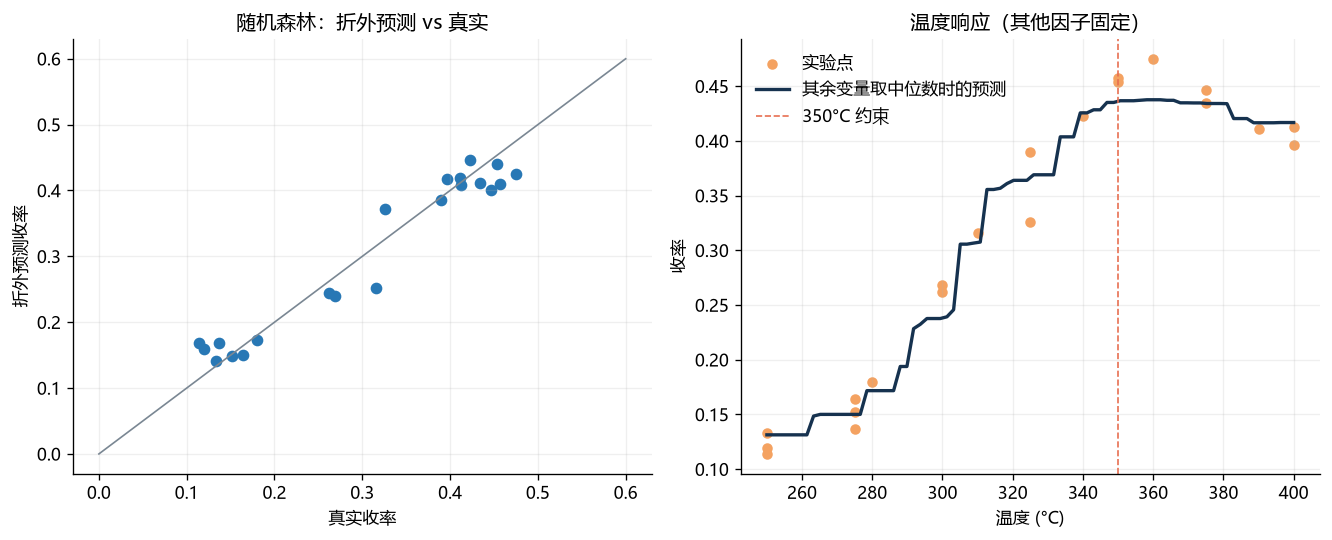

In [4]:
# 用全数据拟合最优模型，做响应面寻优（竞赛里要声明：这是拟合最优，不是外推保证）
best_model = models[best_name]
if best_name == '均值基线':
    best_model = models['二阶Ridge响应面']
    best_name = '二阶Ridge响应面'
best_model.fit(X, y)

grid = {
    'Co负载_wt': np.array([0.5, 1.0, 2.0, 5.0]),
    'HAP装料比': np.array([0.33, 0.50, 0.67]),
    '乙醇流量': np.array([0.9, 1.4, 1.7, 2.1]),
    '温度C': np.arange(250, 405, 5),
}
mesh = np.array(np.meshgrid(*grid.values(), indexing='ij'))
flat = np.vstack([m.ravel() for m in mesh]).T
pred_grid = best_model.predict(flat)
pred_grid = np.clip(pred_grid, 0, 1)

def best_under(mask, label):
    idx = np.argmax(np.where(mask, pred_grid, -1))
    x = flat[idx]
    return {
        '情景': label, 'Co负载_wt': x[0], 'HAP装料比': x[1],
        '乙醇流量': x[2], '温度C': x[3], '预测收率': pred_grid[idx]
    }

opt_tbl = pd.DataFrame([
    best_under(np.ones(len(pred_grid), dtype=bool), '温度不限'),
    best_under(flat[:, 3] <= 350, '温度≤350°C'),
])

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
axes[0].scatter(y, oof[best_name], c=COLORS['blue'], s=36)
axes[0].plot([0, 0.6], [0, 0.6], color=COLORS['gray'], lw=1)
axes[0].set_xlabel('真实收率'); axes[0].set_ylabel('折外预测收率')
axes[0].set_title(f'{best_name}：折外预测 vs 真实')

# 固定其余变量为教学中位数，只看温度
med = eth[feat_cols].median().to_numpy()
Tline = np.linspace(250, 400, 80)
Xline = np.tile(med, (len(Tline), 1)); Xline[:, 3] = Tline
axes[1].scatter(eth['温度C'], eth['收率'], c=COLORS['orange'], s=28, label='实验点')
axes[1].plot(Tline, np.clip(best_model.predict(Xline), 0, 1),
             color=COLORS['navy'], lw=2, label='其余变量取中位数时的预测')
axes[1].axvline(350, color=COLORS['red'], ls='--', lw=1, label='350°C 约束')
axes[1].set_xlabel('温度 (°C)'); axes[1].set_ylabel('收率')
axes[1].set_title('温度响应（其他因子固定）')
axes[1].legend(frameon=False)
fig.tight_layout()
show_result(opt_tbl.round(3), fig)

## 1.5 图表应该怎么解释？

- 左图若点落在对角线附近，说明模型在**没见过的实验组合**上也能工作；若某几个点偏离很大，优先回去看那组实验是不是装料方式特殊。
- 右图说明：温度升高先抬升收率，之后可能变平甚至下降。所以“温度越高越好”通常是错的。
- 约束 $T\le 350$ 后最优点会左移，预测收率下降。论文里这正是“工程约束改变决策”的证据。

## 1.6 可直接用于论文的结果分析思路

1. 先报数据质量：样本数、温度覆盖、有无越界。
2. 再报模型比较表：必须出现均值基线。若随机森林只比 Ridge 好一点点，选 Ridge。
3. 给出不限温度和 $T\le 350$ 两组工艺。
4. 讨论交互：负载高时，高温可能损害选择性。
5. 补实验：在高预测收率且模型分歧大的格子上补 5 点。

## 1.7 正式参赛还应补什么？

- 使用官方附件 1、2 的真实实验，不要用本课随机数；
- 对附件 2 的 350°C 时间序列单独做稳定性分析；
- 用方差分析或似然比检验回答“影响是否显著”；
- 收率预测加 Bootstrap 区间，再做稳健优化；
- 第 4 问用 D-最优 / 期望改进（EI）设计 5 次后续实验。

# 案例二｜2023 美赛 C 题：Predicting Wordle Results

> Wordle 是《纽约时报》的每日猜词游戏。这道题看起来像玩梗，其实是标准的“时间序列 + 特征回归 + 分布预测”。下面按小白能交卷的方式，把每一问该写什么、公式里每个字母是什么，全部摊开。

## 2.1 先用大白话读懂题目

每天一个 5 个字母的单词。很多人把成绩发到 Twitter。题目给了大约一年的日报，每一天有：

- 日期、当天的单词；
- **上报人数 $N_t$**：这一天有多少人在 Twitter 上报告了成绩；
- **困难模式人数**，从而可以算困难模式比例；
- 用 1、2、3、4、5、6 次猜中的百分比，以及没猜中（记为 $X$）的百分比。这 7 个数加起来应当约等于 1。

出题人（纽约时报）要你做三件具体的事，不是“随便分析一下数据”。

## 2.2 每一问在问什么

**第 1 问有两层。**

第一层：上报人数为什么天天不一样？请解释，并给出 **2023 年 3 月 1 日** 上报人数的**预测区间**（不是一个孤零零的整数）。

第二层：单词本身的属性，会不会影响“困难模式”占比？如果会，怎样影响；如果不会，为什么。

**第 2 问：** 将来某一天、某一个具体单词（题目点名 `EERIE`，日期仍是 2023-03-01），请预测 7 个数：$(p_1,p_2,p_3,p_4,p_5,p_6,p_X)$。还要说你有多不确定。

**第 3 问：** 任何有数据支撑的有趣发现都可以写，但必须能指回附件里的列，不能编故事。

## 2.3 教学数据说明

官方附件是一张 Excel。本课生成 2022-01-07 到 2022-12-31 的教学序列：前期用户增长、后期平台，再叠加星期效应；单词难度由重复字母、生僻字母驱动。**词和人数都不是官方数。**

## 2.4 第 1 问怎么写：人数为什么变，区间怎么给

先分清两股力量，不要一上来把“单词难不难”当成人数的主因。

**力量 A：产品自己的生命周期。** Wordle 爆红后人数先涨，再慢慢稳住。用时间 $t=1,2,3,\ldots$（第几天）表示：

$$
\mathrm{Trend}(t) \;=\; \alpha + \beta t
$$

或更软一点的饱和形式 $\alpha + \beta(1-e^{-t/\tau})$。

|符号|人话|
|---|---|
|$t$|从序列第一天数起的整数天数，单位：天|
|$\alpha$|起点附近的基准人数，单位：人|
|$\beta$|每天大致增加多少人；后期若已经平台，这一项会接近 0|
|$\tau$|若用饱和形式：涨速减半大概需要多少天|

**力量 B：星期。** 周三、周四往往更活跃，周末可能更低。引入哑变量：

$$
\mathrm{Dow}(t) \;=\; \sum_{d=1}^{6} \gamma_d \,\mathbf{1}\{\text{星期几}(t)=d\}.
$$

|符号|人话|
|---|---|
|$\mathbf{1}\{\cdot\}$|括号里成立则为 1，否则为 0。例如今天是周三，只有 $d=3$ 那一项是 1|
|$\gamma_d$|这个星期几相对于“被省略的那个星期几”（常取周一或周日当基准）平均多或少多少人|
|$d=1,\ldots,6$|只放 6 个，第 7 个当基准，否则 7 个哑变量会和截距线性相关，方程解不唯一|

**力量 C：惯性。** 昨天人多，今天往往也人多：

$$
N_t \;=\; \alpha + \beta t + \mathrm{Dow}(t) + \theta_1 N_{t-1} + \theta_7 N_{t-7} + \varepsilon_t.
$$

|符号|人话|
|---|---|
|$N_t$|第 $t$ 天实际上报人数，单位：人|
|$N_{t-1}$|昨天的人数，叫 1 阶滞后|
|$N_{t-7}$|上周同一天的人数，用来抓周循环|
|$\theta_1,\theta_7$|滞后系数。$\theta_1=0.6$ 表示昨天多 1000 人，今天平均还多 600 人|
|$\varepsilon_t$|残差：新闻、假期、服务器故障等模型没写进去的东西|

**绝对不能随机打乱做 8:2。** 人数有时间顺序，随机切会把“明天”泄漏给“今天”。正确做法：前面大部分天训练，**最后 28 天**当测试。

基线：不建模，只拿“历史上同一个星期几的平均人数”来猜。你的模型必须先打败这个基线，才有资格写进摘要。

点预测还不够。题目要**区间**。用训练集残差 $\hat\varepsilon_t = N_t - \hat N_t$ 的分位数：

$$
\bigl[\,\hat N_t + q_{0.05}(\hat\varepsilon),\;\hat N_t + q_{0.95}(\hat\varepsilon)\,\bigr].
$$

|符号|人话|
|---|---|
|$\hat N_t$|模型给出的点预测|
|$q_{0.05}(\hat\varepsilon)$|训练残差从小到大排，大约 5% 位置的那个数，通常是负数|
|$q_{0.95}$|大约 95% 位置，通常是正数|
|方括号|预报区间。不是“未来一定落在这里”，而是“按过去误差的尺度，大约 90% 的天会落在这里”|

在测试的 28 天上算覆盖率：

$$
\mathrm{Coverage} \;=\; \frac{1}{28}\sum_{t\in\mathrm{测试}}\mathbf{1}\bigl\{N_t\in[\hat L_t,\hat U_t]\bigr\}.
$$

若你管它叫 90% 区间，覆盖率就应该靠近 0.90。覆盖率只有 0.50，说明区间太窄，在吹牛；覆盖率 1.00 但区间从 0 到 10 万，说明太宽，没有信息。

预报 2023-03-01：从样本最后一天开始，用预测值当作新的 $N_{t-1}$、$N_{t-7}$，一天一天推到目标日，再套上同一套分位区间。论文里必须写：这是递推预报，误差会累积。

**第 1 问后半：困难模式比例。** 令 $h_t$ 为当天困难模式人数 / 上报人数。单词特征

$$
f(w) \;=\; \bigl(\mathrm{vowels},\;\mathrm{unique},\;\mathrm{repeat},\;\mathrm{rare},\;\mathrm{common\_start}\bigr).
$$

|符号|人话|例子|
|---|---|---|
|$\mathrm{vowels}$|元音 a,e,i,o,u 出现几次|CRANE 有 2 个|
|$\mathrm{unique}$|不同字母有几个|EERIE 只有 3 个不同字母|
|$\mathrm{repeat}$|有没有重复字母，0 或 1|EERIE 为 1|
|$\mathrm{rare}$|q,j,z,x,v,k 这种少见字母出现几次|JAZZY 很多|
|$\mathrm{common\_start}$|首字母是不是 s,t,a,c,b 这种常见开头|

回归：

$$
h_t \;=\; \delta_0 + \delta^\top f(w_t) + \xi_t.
$$

|符号|人话|
|---|---|
|$h_t$|困难模式比例，在 0 和 1 之间|
|$\delta_0$|一个“普通词”的基准困难模式比例|
|$\delta$|五个特征各自的回归系数。例如 $\delta_{\mathrm{repeat}}>0$ 表示重复字母的词，更多人开困难模式|
|$\xi_t$|残差|

若所有 $\delta$ 的 $p$ 值都很大，论文就写：**没有证据表明词属性影响困难模式比例**，并解释可能是因为开不开困难模式更像个人习惯，和当天单词关系弱。不要为了“有模型”硬说有影响。

## 2.5 第 2 问怎么写：预测一整条分布

要预测的不是一个数，是 7 个概率

$$
p(w) \;=\; \bigl(p_1,p_2,p_3,p_4,p_5,p_6,p_X\bigr),\qquad \sum p_k=1,\; p_k\ge 0.
$$

|符号|人话|
|---|---|
|$p_1$|用 1 次就猜中的比例，通常很小|
|$p_2,\ldots,p_6$|用 2 到 6 次猜中的比例|
|$p_X$|6 次仍没猜中的比例|

本课用最容易讲清的做法：先算全体（或训练期）的平均分布 $\bar p$，再按单词难度把质量往右推。

难度分数：

$$
\mathrm{diff}(w) \;=\; \mathbf{1}_{\mathrm{repeat}} + 0.8\,\mathrm{rare} - 0.15\,\mathrm{vowels}.
$$

|符号|人话|为什么这样设|
|---|---|---|
|$\mathbf{1}_{\mathrm{repeat}}$|有重复字母为 1|重复字母少一条新信息，更难|
|$\mathrm{rare}$|生僻字母个数|少见字母更难想到|
|$0.8$|生僻字母的权重，教学取值；正式参赛应用回归重估|
|$0.15$|元音多一点往往更好猜，所以是减号|

平移：

$$
\hat p(w) \;=\; \mathrm{normalize}\bigl(\bar p + \hat\kappa\cdot \mathrm{diff}(w)\bigr).
$$

|符号|人话|
|---|---|
|$\bar p$|训练期 7 维平均分布，是“普通词”的样子|
|$\hat\kappa$|7 维系数，用训练期 $(\mathrm{diff}_t,\; p_t-\bar p)$ 做最小二乘得到。它告诉你：难度每增加 1，1 次命中会少多少、6 次和 X 会多多少|
|$\mathrm{normalize}$|把向量里的负数裁成很小的正数，再除以总和，保证是合法概率|

`EERIE` 有三个 E，重复字母 $=1$，元音也多。重复会加大 $\mathrm{diff}$，所以预测应比普通词更靠 5、6、$X$。论文里把 7 个数列表，并写一句：“重复字母降低了每步获得的新信息。”

不确定性：对训练天做 bootstrap（有放回重抽样，重估 $\hat\kappa$ 1000 次），得到每档的 5%～95% 分位。只交 7 个点、不交区间，第 2 问会偏弱。

评价分布预测：

$$
\mathrm{MAE}_{\mathrm{bin}} \;=\; \frac{1}{7}\sum_{k}|p_k-\hat p_k|,
\qquad
\mathrm{KL}(p\Vert\hat p) \;=\; \sum_{k} p_k \log\frac{p_k}{\hat p_k}.
$$

KL 越小越好，它惩罚“真实很多、你却预测接近 0”的档。

In [5]:
def word_features(word):
    w = word.lower()
    vowels = sum(ch in 'aeiou' for ch in w)
    rare = sum(ch in 'qjzxvk' for ch in w)
    return {
        '单词': word.upper(),
        '元音数': vowels,
        '唯一字母': len(set(w)),
        '重复字母': int(len(w) != len(set(w))),
        '生僻字母': rare,
        '首字母常见': int(w[0] in 'stacb'),
    }

# 教学词表：覆盖重复字母、生僻字母、普通词
WORDS = [
    'TRITE','EERIE','CRANE','PROXY','JAZZY','VIVID','STARE','QUIET',
    'SLOTH','KNOLL','APPLE','SNAKE','WOULD','LIGHT','QUERY','ZEBRA',
    'CIVIC','KAYAK','BLUFF','CHARM','GHOST','PRIDE','STORM','QUILT',
    'FROST','MANGO','BRAVE','PLUMB','VIXEN','SWEET'
]

dates = pd.date_range('2022-01-07', '2022-12-31', freq='D')
r = np.random.default_rng(SEED)
words = [WORDS[i % len(WORDS)] for i in range(len(dates))]
# 增长 + 平台 + 星期：周三周四更高，周日更低
t = np.arange(len(dates))
trend = 18000 + 22000 * (1 - np.exp(-t / 55))
dow = dates.dayofweek
week_eff = np.array([0.92, 1.00, 1.06, 1.08, 1.02, 0.96, 0.88])[dow]
noise = r.lognormal(0, 0.06, len(dates))
reports = (trend * week_eff * noise).astype(int)

feat = pd.DataFrame([word_features(w) for w in words])
# 困难模式：周末略高，重复字母/生僻字母更高
hard = 0.07 + 0.015 * feat['重复字母'] + 0.012 * feat['生僻字母']
hard += 0.01 * (dow >= 5) + r.normal(0, 0.008, len(dates))
hard = np.clip(hard, 0.04, 0.22)

# 猜测分布：难度越高，质量向 5、6、X 移动
base = np.array([0.01, 0.06, 0.24, 0.33, 0.22, 0.11, 0.03])
diff = (feat['重复字母'] + 0.8 * feat['生僻字母'] - 0.15 * feat['元音数']).to_numpy()
dist = []
for d in diff:
    shift = np.array([0, -0.01, -0.03, -0.02, 0.02, 0.025, 0.015]) * (d + 0.2)
    p = np.clip(base + shift + r.normal(0, 0.006, 7), 0.002, None)
    p = p / p.sum()
    dist.append(p)
dist = np.array(dist)

wordle = pd.DataFrame({
    '日期': dates, '单词': feat['单词'], '上报人数': reports,
    '困难模式比例': hard, '星期': dates.day_name()
}).join(feat.drop(columns='单词'))
for i, col in enumerate(['p1','p2','p3','p4','p5','p6','pX']):
    wordle[col] = dist[:, i]

print('教学序列天数：', len(wordle), '；人数范围：', wordle['上报人数'].min(), '–', wordle['上报人数'].max())
show_result(wordle[['日期','单词','上报人数','困难模式比例','重复字母','生僻字母']].head(8))

教学序列天数： 359 ；人数范围： 14753 – 48106


,日期,单词,上报人数,困难模式比例,重复字母,生僻字母
0,2022-01-07,TRITE,17506,0.077263,1,0
1,2022-01-08,EERIE,17917,0.111094,1,0
2,2022-01-09,CRANE,14753,0.075354,0,0
3,2022-01-10,PROXY,19174,0.076150,0,1
4,2022-01-11,JAZZY,20306,0.123142,1,3
5,2022-01-12,VIVID,20739,0.117249,1,2
6,2022-01-13,STARE,21489,0.065192,0,0
7,2022-01-14,QUIET,21428,0.077203,0,1


人数预测必须同时交点估计和区间。覆盖率接近 90% 才配叫 90% 区间。


,模型,RMSE,MAE,MAPE,sMAPE,R2
0,星期均值基线,3954.970,3420.332,0.085,0.089,-0.267
1,趋势+滞后线性,3039.899,2378.997,0.062,0.060,0.251
2,Ridge,3036.914,2375.315,0.061,0.060,0.253


,目标日,点预测,90%经验下限,90%经验上限,测试集区间覆盖率
0,2023-03-01,47405,43397,51765,0.821


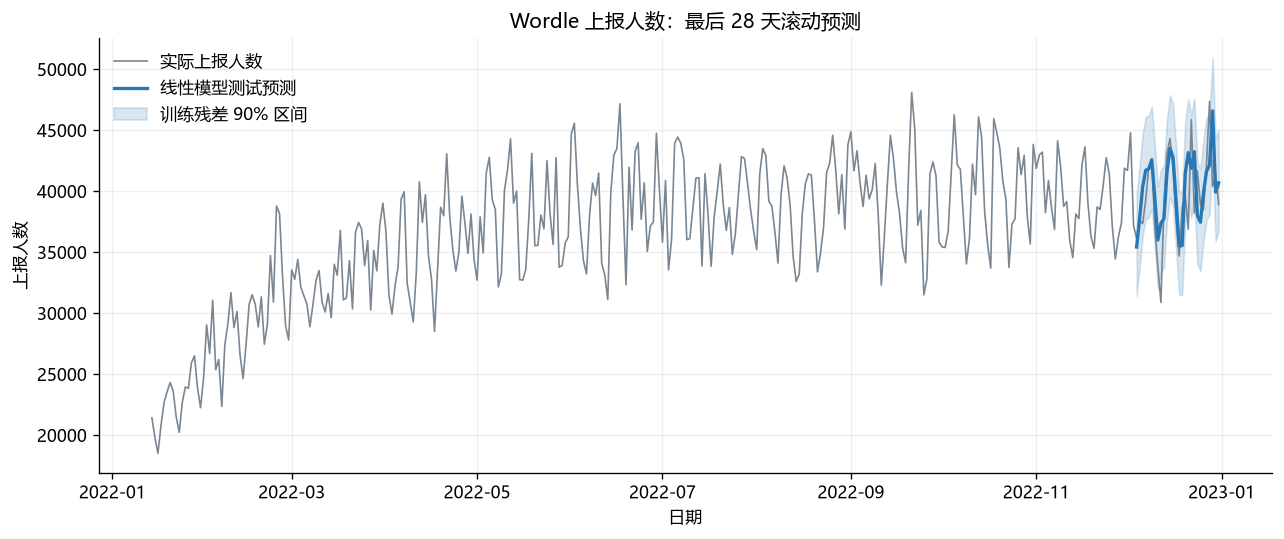

In [6]:
w = wordle.copy()
w['t'] = np.arange(len(w))
w['lag1'] = w['上报人数'].shift(1)
w['lag7'] = w['上报人数'].shift(7)
w = w.dropna().reset_index(drop=True)
dummy = pd.get_dummies(w['日期'].dt.dayofweek, prefix='dow', drop_first=True)
Xw = pd.concat([w[['t', 'lag1', 'lag7']], dummy], axis=1).to_numpy(dtype=float)
yw = w['上报人数'].to_numpy(dtype=float)

n_te = 28
tr, te = slice(0, -n_te), slice(-n_te, None)
# 朴素基线：星期均值
dow_mean = w.iloc[tr].groupby(w.iloc[tr]['日期'].dt.dayofweek)['上报人数'].mean()
base_pred = w.iloc[te]['日期'].dt.dayofweek.map(dow_mean).to_numpy()

lin = LinearRegression().fit(Xw[tr], yw[tr])
ridge = Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=3.0))]).fit(Xw[tr], yw[tr])
pred_lin, pred_ridge = lin.predict(Xw[te]), ridge.predict(Xw[te])

cmp = pd.DataFrame([
    regression_report(yw[te], base_pred, '星期均值基线'),
    regression_report(yw[te], pred_lin, '趋势+滞后线性'),
    regression_report(yw[te], pred_ridge, 'Ridge'),
])

resid = yw[tr] - lin.predict(Xw[tr])
lo, hi = np.quantile(resid, [0.05, 0.95])
cover = np.mean((yw[te] >= pred_lin + lo) & (yw[te] <= pred_lin + hi))

# 推到 2023-03-01：用最后一天递推 60 天，只为演示区间，不是真实预报
last_row = Xw[-1].copy()
steps = (pd.Timestamp('2023-03-01') - w['日期'].iloc[-1]).days
yhat = yw[-1]
hist = list(yw)
for s in range(steps):
    last_t = last_row[0] + 1
    lag1 = hist[-1]
    lag7 = hist[-7]
    dow = (w['日期'].iloc[-1] + pd.Timedelta(days=s + 1)).dayofweek
    x = np.zeros_like(last_row)
    x[0], x[1], x[2] = last_t, lag1, lag7
    if dow > 0:
        x[2 + dow] = 1.0   # dow_1 ... corresponding to get_dummies drop_first
    yhat = float(lin.predict(x.reshape(1, -1))[0])
    hist.append(yhat)
    last_row = x

future_tbl = pd.DataFrame({
    '目标日': ['2023-03-01'],
    '点预测': [int(yhat)],
    '90%经验下限': [int(yhat + lo)],
    '90%经验上限': [int(yhat + hi)],
    '测试集区间覆盖率': [cover],
})

fig, ax = plt.subplots(figsize=(10.8, 4.6))
ax.plot(w['日期'], yw, color=COLORS['gray'], lw=1, label='实际上报人数')
ax.plot(w['日期'].iloc[te], pred_lin, color=COLORS['blue'], lw=2, label='线性模型测试预测')
ax.fill_between(w['日期'].iloc[te], pred_lin + lo, pred_lin + hi,
                color=COLORS['blue'], alpha=0.18, label='训练残差 90% 区间')
ax.set_xlabel('日期'); ax.set_ylabel('上报人数')
ax.set_title('Wordle 上报人数：最后 28 天滚动预测')
ax.legend(frameon=False)
fig.tight_layout()
print('人数预测必须同时交点估计和区间。覆盖率接近 90% 才配叫 90% 区间。')
show_result(cmp.round(3))
show_result(future_tbl.round(3), fig)

困难模式回归 R2 = 0.671 。EERIE 有重复字母，质量应更靠右。


,结果,预测比例,教学数据中同类词均值
0,1次,0.010,0.009
1,2次,0.050,0.044
2,3次,0.209,0.192
3,4次,0.310,0.298
4,5次,0.240,0.252
5,6次,0.136,0.151
6,X,0.045,0.054


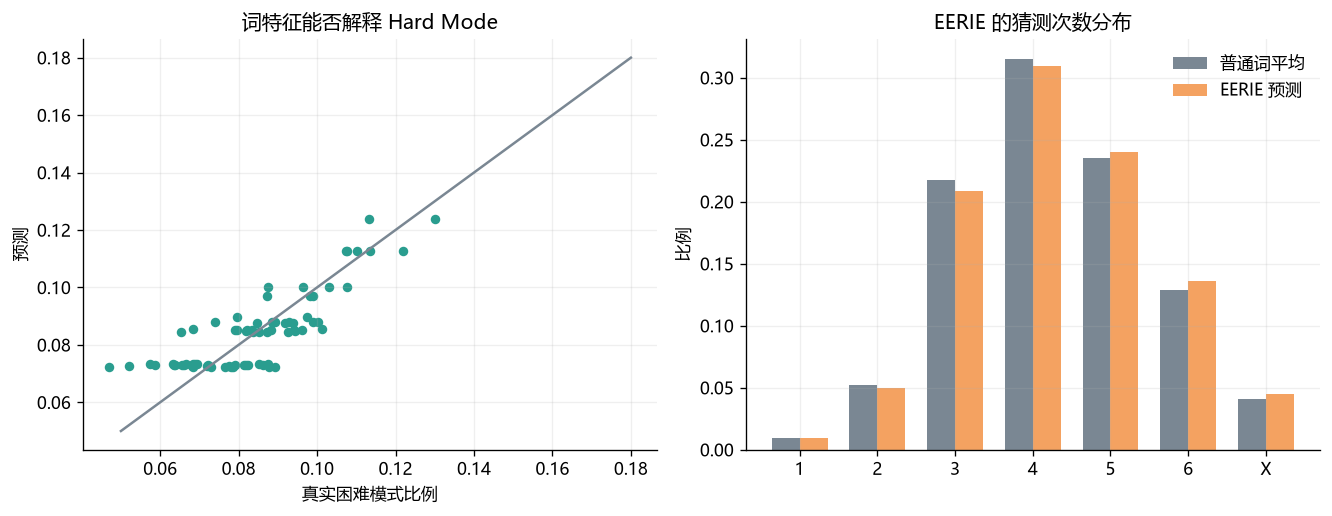

In [7]:
# 词特征 → 困难模式比例；猜测分布用“难度分数”平移
Xh = wordle[['元音数','唯一字母','重复字母','生僻字母','首字母常见']].to_numpy()
yh = wordle['困难模式比例'].to_numpy()
# 按时间切，避免把后期平台期随机泄漏
cut = int(len(wordle) * 0.8)
m_hard = LinearRegression().fit(Xh[:cut], yh[:cut])
hard_hat = m_hard.predict(Xh[cut:])
hard_rep = regression_report(yh[cut:], hard_hat, '词特征线性')

# 难度分数
score = (wordle['重复字母'] + 0.8 * wordle['生僻字母'] - 0.15 * wordle['元音数']).to_numpy()
# 用训练期平均分布 + 线性平移系数，预测 EERIE
cols = ['p1','p2','p3','p4','p5','p6','pX']
base_p = wordle.loc[:cut-1, cols].mean().to_numpy()
# 最小二乘估计平移强度
Yd = wordle.loc[:cut-1, cols].to_numpy() - base_p
coef = np.linalg.lstsq(score[:cut].reshape(-1, 1), Yd, rcond=None)[0][0]

eerie = word_features('EERIE')
e_score = eerie['重复字母'] + 0.8 * eerie['生僻字母'] - 0.15 * eerie['元音数']
e_p = np.clip(base_p + coef * e_score, 1e-3, None)
e_p = e_p / e_p.sum()
eerie_tbl = pd.DataFrame({
    '结果': ['1次','2次','3次','4次','5次','6次','X'],
    '预测比例': e_p,
    '教学数据中同类词均值': wordle.loc[wordle['重复字母']==1, cols].mean().to_numpy()
})

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))
axes[0].scatter(yh[cut:], hard_hat, c=COLORS['cyan'], s=22)
axes[0].plot([0.05, 0.18], [0.05, 0.18], color=COLORS['gray'])
axes[0].set_xlabel('真实困难模式比例'); axes[0].set_ylabel('预测')
axes[0].set_title('词特征能否解释 Hard Mode')
axes[1].bar(np.arange(7)-0.18, base_p, width=0.36, color=COLORS['gray'], label='普通词平均')
axes[1].bar(np.arange(7)+0.18, e_p, width=0.36, color=COLORS['orange'], label='EERIE 预测')
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(['1','2','3','4','5','6','X'])
axes[1].set_ylabel('比例'); axes[1].set_title('EERIE 的猜测次数分布')
axes[1].legend(frameon=False)
fig.tight_layout()
print('困难模式回归 R2 =', round(hard_rep['R2'], 3), '。EERIE 有重复字母，质量应更靠右。')
show_result(eerie_tbl.round(3), fig)

## 2.5 结果怎么读？

- 上报人数的主驱动往往是**产品生命周期 + 星期**，单词本身通常是次要的。所以第 1 问先做时序，再检查词特征。
- `EERIE` 有重复 `E`，信息量低，预测分布应比普通词更向 5、6、X 倾斜。
- 经验区间不是贝叶斯可信区间；测试覆盖率必须写进论文，否则“90% 区间”只是名字。

## 2.6 正式参赛还应补什么？

- 使用官方 `Problem C Data Wordle.xlsx`；
- 人数模型可加 Twitter 活跃度、新闻冲击、假期；
- 分布预测可改成多项逻辑回归或 Dirichlet 回归；
- 对 `EERIE` 给出 bootstrap 区间，而不是只给 7 个点；
- 讨论：Twitter 自报样本有偏，不能代表全部玩家。

# 案例三｜2025 国赛 C 题：NIPT 的时点选择与胎儿异常判定

> 这是近年国赛 C 题里最典型的“先预测、再决策、再分类”。医学背景只需要记住三句话：抽的是孕妇的血；血里有一点点胎儿的 DNA；男胎多了一条 Y 染色体，所以可以用 Y 的比例判断“这次检测准不准”。下面按四问，用小白能写进论文的语言把公式摊开。

## 3.1 先用大白话读懂题目

NIPT = 无创产前检测。医生关心胎儿 21、18、13 号染色体是不是多了一条（唐氏、爱德华、帕陶综合征）。

题面给了两个硬门槛，写作文时必须反复用到：

1. **准不准。** 男胎：Y 染色体浓度达到或超过 **4%**，才认为这次结果基本准确。女胎没有 Y，题面改用 X 和其他染色体的 Z 值。
2. **早晚。** 发现不健康胎儿越晚，治疗窗口越短。题面把风险粗分成：12 周及以前较低，13–27 周较高，28 周及以后极高。

实践经验：Y 浓度会随**孕周**升高（胎儿 DNA 越来越多），又会被高 **BMI**（身体质量指数，体重除以身高的平方）压低——同样孕周，偏胖的孕妇血液被稀释得更厉害，Y 比例更低，达标更晚。

所以“所有人统一 12 周来抽血”并不公平：瘦的可能早就达标，胖的可能还没到 4%，测了等于白测。

附件里还有测序失败、同一人多次抽血。这些不是脏数据，是机制的一部分。

## 3.2 四问分别要你交什么

**第 1 问：** 分析 Y 浓度和孕周、BMI 等的关系，给出关系模型，并做显著性检验。  
交：相关表 + 回归方程 + 每个系数的 $p$ 值 + 一张散点图。

**第 2 问：** 男胎按 BMI 合理分组，给出每组区间和最佳 NIPT 时点，让潜在风险最小，并分析检测误差。  
交：分组表（几组、每组 BMI 从哪到哪、建议哪一周抽血）+ 误差扰动后时点动不动。

**第 3 问：** 再加入身高、体重、年龄、达标比例、检测误差，重新分组和选时点。  
交：比第 2 问更细的模型，而不是换一套完全无关的方法。

**第 4 问：** 女胎没有 Y，用 13/18/21 和 X 的 Z 值、GC 含量等，判断女胎是否异常。  
交：分类器 + 混淆矩阵 + 你怎样选阈值。

## 3.3 教学数据说明

官方附件是真实孕妇队列，字段很多（孕周写成“12周+3天”、多次检测）。本课生成约 260 名教学孕妇：BMI 偏高、每人 1–3 次检测、Y 浓度随孕周升、随 BMI 降，并随机制造少量测序失败。**不能当作临床结论。**

## 3.4 第 1 问怎么写：相关、回归、显著性

孕周在附件里常常是“12w+3d”。先换成连续数：

$$
g \;=\; \mathrm{周} + \frac{\mathrm{天}}{7}.
$$

|符号|人话|例子|
|---|---|---|
|$g$|连续孕周，单位：周|12 周 + 3 天 $\Rightarrow g=12+3/7\approx 12.43$|
|周、天|题面原始字段|不要把 12+3 当成 12.3，那是错的|

BMI：

$$
\mathrm{BMI} \;=\; \frac{W}{(H/100)^2}.
$$

|符号|人话|单位|
|---|---|---|
|$W$|体重|千克|
|$H$|身高|厘米。除以 100 变成米，否则数量级全错|

对**有效男胎记录**（Y 浓度不是空、也不是测序失败）写：

$$
Y_i \;=\; \beta_0 + \beta_1 g_i + \beta_2 \,\mathrm{BMI}_i + \beta_3 \,\mathrm{Age}_i + \varepsilon_i.
$$

|符号|人话|预期符号|
|---|---|---|
|$Y_i$|第 $i$ 条记录的 Y 染色体浓度|百分数，例如 4.2 表示 4.2%。题面门槛是 4|
|$g_i$|这次抽血时的孕周|预期 $\beta_1>0$：越晚，胎儿 DNA 越多|
|$\mathrm{BMI}_i$|孕妇当时的身体质量指数|预期 $\beta_2<0$：越高越稀释|
|$\mathrm{Age}_i$|年龄，岁|可正可负，让数据说话|
|$\beta_0$|形式上的截距：三个自变量都为 0 时的浓度。0 岁 0 孕周没有意义，解释时改说“在样本均值附近的基准浓度”|
|$\beta_1$|孕周增加 1 周，Y 浓度平均升高多少个百分点|
|$\beta_2$|BMI 增加 1，Y 浓度平均变化多少个百分点|
|$\beta_3$|年龄增加 1 岁的平均变化|
|$\varepsilon_i$|这条记录没被模型吃掉的残差，假定均值为 0|

显著性：对每个 $\beta_j$ 检验 $H_0:\beta_j=0$。软件会给 $t$ 统计量和 $p$ 值。

$$
t_j \;=\; \frac{\hat\beta_j}{\mathrm{se}(\hat\beta_j)}.
$$

|符号|人话|
|---|---|
|$\hat\beta_j$|用数据估出来的系数|
|$\mathrm{se}(\hat\beta_j)$|这个估计有多晃，叫标准误。样本少或这个变量变化小，标准误就大|
|$t_j$|系数是“晃动幅度”的多少倍。绝对值大，更不像零|
|$p$ 值|如果真实系数真是 0，看到这么极端结果的概率。竞赛里常以 0.05 为门槛，但要同时写清系数大小|

还要报 $R^2$：模型解释了 Y 浓度多少波动。本课教学数据里孕周和 BMI 都强，所以 $R^2$ 会比较高；真实附件可能更吵，低一些也正常。

**同一孕妇多次检测并不独立。** 正式参赛应写成混合效应：

$$
Y_{ij} \;=\; \beta^\top x_{ij} + u_i + \varepsilon_{ij},\qquad u_i\sim N(0,\tau^2).
$$

|符号|人话|
|---|---|
|$Y_{ij}$|第 $i$ 个孕妇第 $j$ 次检测的浓度|
|$x_{ij}$|这次的孕周、BMI、年龄等|
|$u_i$|这个孕妇自己的“基准高低”，有的人天生浓度偏高一点|
|$\tau^2$|$u_i$ 在人群里散开的程度。$\tau$ 大说明个体差异不能忽视|
|$\varepsilon_{ij}$|同一次检测的噪声|

第 1 问如果只用普通 OLS，论文局限里必须写“忽略了多次测量相关”。

## 3.5 第 2 问怎么写：分组 + 最佳时点

最佳时点**不是**“该组平均达标周”。太早：很多人还没到 4%，测了不准；太晚：即使准了，发现得太迟。要在这两害之间折中。

**第一步：估计每人最早达标周 $\hat T_i$。**

- 若这个人已经有 $Y\ge 4$ 的记录，取这些记录里最小的孕周。
- 若一直没达标，用她自己的两点或几点拟合 $Y=\hat a_i+\hat b_i g$，令 $Y=4$ 反解

$$
\hat T_i \;=\; \mathrm{clip}\Bigl(\frac{4-\hat a_i}{\hat b_i},\; 10,\; 30\Bigr).
$$

|符号|人话|
|---|---|
|$\hat a_i$|这个人自己的直线截距|
|$\hat b_i$|她的浓度随孕周上升的斜率。若 $\hat b_i$ 几乎为 0，不能乱除，应把 $\hat T_i$ 记成很晚（本课 clip 到 30 周）|
|$4$|题面给的达标门槛，单位与 $Y$ 相同|
|$\mathrm{clip}(\cdot,10,30)$|把结果限制在 10 到 30 周，避免外推出负周或 80 周这种胡说|

**第二步：按 BMI 分组。** 题面举例 $[20,28),[28,32),[32,36),[36,40),40+$。你可以沿用，也可以用分位数或聚类，但必须说明：组不能太碎（每组至少十几个人），边界最好落在整数，方便临床执行。

**第三步：组内选时点。** 组 $G$ 里，候选时点 $t$（比如 11 周、11.5 周，……，24 周），定义代价

$$
J_G(t) \;=\; C\cdot \underbrace{\frac{1}{|G|}\#\{i\in G:\hat T_i > t\}}_{\text{到 }t\text{ 周仍未达标的比例}} + R(t).
$$

延误风险按题意分段，并加一点连续项，避免所有组都挤在刚好 12 周：

$$
R(t) \;=\;
\begin{cases}
1, & t\le 12,\\
3 + 0.12(t-12), & 12 < t \le 27,\\
8 + 0.3(t-27), & t>27.
\end{cases}
$$

|符号|人话|
|---|---|
|$t$|你准备建议的抽血孕周|
|$|G|$|这一组有多少名孕妇|
|$\#\{\hat T_i>t\}$|到你建议的那一周，估计还没达标的人数|
|$C$|“测了不准”相对于“晚发现一点”的代价。本课取 $C=6$，表示宁可稍晚也要准。正式参赛应用专家打分或临床文献标定|
|$R(t)$|发现得晚的风险分数。12 周以内记 1，中期从 3 往上加，28 周以后从 8 往上加|
|$0.12,0.3$|让风险在区间内部随 $t$ 慢慢涨，避免 12.1 周和 26 周风险完全一样|
|$J_G(t)$|这个时点的总代价，越小越好|

$$
t_G^\star \;=\; \arg\min_t J_G(t).
$$

这就是该组的最佳 NIPT 时点。高 BMI 组的 $t_G^\star$ 通常更靠后，但不应拖进极高风险区。

**检测误差：** 给 $\hat T_i$ 加上标准差约 0.6 周的噪声（模拟浓度测不准），再重算 $t_G^\star$。若各组时点只挪 0.5～1 周，写“分组稳健”；若高 BMI 小组剧烈跳动，建议这些组重复抽血。

## 3.6 第 3 问怎么写：多因素，不要另起炉灶

第 3 问不是换一套完全不同的方法，而是把 $\hat T_i$ 从“只看 BMI”升级：

$$
\hat T_i \;=\; \gamma_0 + \gamma_1\mathrm{BMI}_i + \gamma_2\mathrm{Age}_i + \gamma_3 H_i + \gamma_4 W_i + \nu_i.
$$

然后可以：

- 仍按 BMI 分组，但组内用这个更准的 $\hat T_i$ 去算 $J_G(t)$；或
- 直接对 $\hat T_i$ 做聚类，得到“达标早晚类型”，再对每类选时点。

还要把“达标比例”写进 $J$：如果某组到 16 周仍有 40% 不达标，即使平均达标周看起来还行，时点也该后移或安排复查。

## 3.7 第 4 问怎么写：女胎异常是分类，不是再回归一次浓度

女胎没有可用的 Y。标签是附件里 13/18/21 非整倍体是否异常。特征包括各染色体 Z 值、GC 含量、读段数、BMI。

Z 值题面已给：

$$
Z \;=\; \frac{X-\mu}{\sigma}.
$$

|符号|人话|
|---|---|
|$X$|这个样本目标染色体的相对计数比例|
|$\mu$|正常对照人群里这个比例的平均值|
|$\sigma$|正常人群里这个比例的标准差|
|$Z$|偏离正常人群多少个标准差。$|Z|$ 很大，更像异常|

分类器可以用逻辑回归。阈值 $\tau$ 不要默认 0.5，因为漏掉一个异常胎儿（假阴性）比多做一次复查（假阳性）贵得多：

$$
\min_{\tau}\ \lambda\,\mathrm{FNR}(\tau) + (1-\lambda)\,\mathrm{FPR}(\tau).
$$

|符号|人话|
|---|---|
|$\mathrm{FNR}$|假阴性率：真实异常，你却判正常。医学上很危险|
|$\mathrm{FPR}$|假阳性率：真实正常，你却报警，导致不必要的羊穿等|
|$\lambda\in(0,1)$|你有多讨厌漏诊。$\lambda=0.8$ 表示主要压假阴性|
|$\tau$|概率阈值，超过它就判异常|

论文必须交混淆矩阵，并声明正类是“异常”。只报准确率在不平衡标签下会骗人。

In [8]:
def parse_week(week, day):
    return week + day / 7.0

def make_nipt(n_women=260, seed=2026):
    r = np.random.default_rng(seed)
    rows = []
    for i in range(n_women):
        age = r.integers(22, 42)
        height = r.normal(160, 5.5)
        bmi = np.clip(r.normal(31.5, 4.8), 20.5, 46)
        weight = bmi * (height / 100) ** 2
        # 每人 1–3 次检测
        n_test = int(r.choice([1, 2, 3], p=[0.55, 0.35, 0.10]))
        week0 = r.uniform(10.0, 16.5)
        for k in range(n_test):
            gw = week0 + k * r.uniform(1.5, 3.5)
            if gw > 26:
                break
            # 浓度：随孕周上升，高 BMI 压低，高龄略降
            yconc = 1.6 + 0.28 * gw - 0.11 * (bmi - 28) - 0.02 * (age - 30)
            yconc += 0.008 * gw * np.tanh((32 - bmi) / 6)
            yconc += r.normal(0, 0.45)
            fail = r.random() < (0.08 if gw < 11.5 else 0.03)
            rows.append({
                '孕妇': i, '年龄': age, '身高cm': height, '体重kg': weight,
                'BMI': bmi, '孕周': gw, '抽血次数': k + 1,
                'Y浓度': np.nan if fail else max(yconc, 0.2),
                '测序失败': int(fail)
            })
    return pd.DataFrame(rows)

nipt = make_nipt()
male = nipt.dropna(subset=['Y浓度']).copy()
male['达标'] = (male['Y浓度'] >= 4.0).astype(int)
print('检测次数', len(nipt), '；有效男胎记录', len(male),
      '；失败率', nipt['测序失败'].mean().round(3))
show_result(male[['孕妇','年龄','BMI','孕周','Y浓度','达标']].head(8))

检测次数 404 ；有效男胎记录 391 ；失败率 0.032


,孕妇,年龄,BMI,孕周,Y浓度,达标
0,0,39,22.397634,12.306963,5.432582,1
1,1,25,30.415637,15.979026,5.902935,1
2,1,25,30.415637,19.130817,6.648721,1
3,1,25,30.415637,20.090623,6.482644,1
4,2,23,30.786083,12.373675,5.524612,1
5,3,30,25.886258,15.183505,6.552621,1
6,3,30,25.886258,17.810260,7.237066,1
7,4,22,35.708247,14.555466,5.573549,1


OLS R2=0.814，调整R2=0.812


,Y浓度,孕周,BMI,年龄
Y浓度,1.000,0.731,-0.545,-0.121
孕周,0.731,1.000,-0.033,-0.073
BMI,-0.545,-0.033,1.000,-0.041
年龄,-0.121,-0.073,-0.041,1.000


,系数,标准误,t,p值
const,5.0579,0.2470,20.4757,0.0
孕周,0.2932,0.0091,32.1088,0.0
BMI,-0.1129,0.0047,-23.9173,0.0
年龄,-0.0162,0.0039,-4.1407,0.0


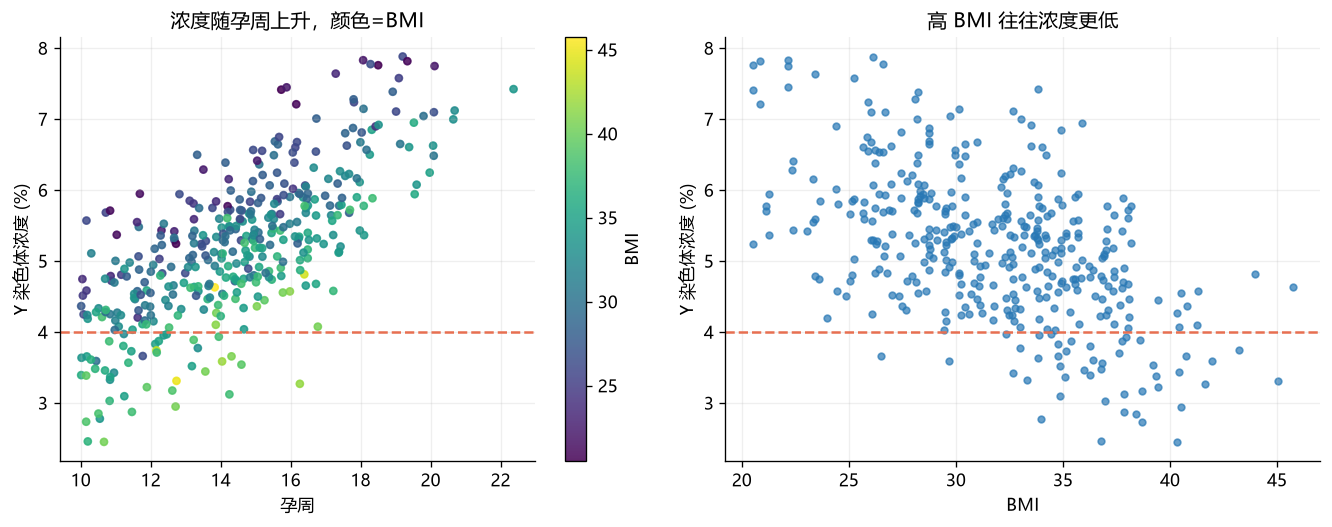

In [9]:
# 问题 1：相关 + 回归 + 显著性
corr_tbl = male[['Y浓度','孕周','BMI','年龄']].corr().round(3)

if HAS_SM:
    X = sm.add_constant(male[['孕周','BMI','年龄']])
    ols = sm.OLS(male['Y浓度'], X).fit()
    coef_tbl = pd.DataFrame({
        '系数': ols.params, '标准误': ols.bse, 't': ols.tvalues, 'p值': ols.pvalues
    })
    print(f'OLS R2={ols.rsquared:.3f}，调整R2={ols.rsquared_adj:.3f}')
else:
    lr = LinearRegression().fit(male[['孕周','BMI','年龄']], male['Y浓度'])
    coef_tbl = pd.DataFrame({'系数': [lr.intercept_, *lr.coef_]},
                            index=['const','孕周','BMI','年龄'])
    print('未安装 statsmodels，仅给出点估计。')

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5))
sc = axes[0].scatter(male['孕周'], male['Y浓度'], c=male['BMI'],
                     cmap='viridis', s=18, alpha=0.85)
axes[0].axhline(4, color=COLORS['red'], ls='--', label='4% 达标线')
axes[0].set_xlabel('孕周'); axes[0].set_ylabel('Y 染色体浓度 (%)')
axes[0].set_title('浓度随孕周上升，颜色=BMI')
plt.colorbar(sc, ax=axes[0], label='BMI')
axes[1].scatter(male['BMI'], male['Y浓度'], c=COLORS['blue'], s=16, alpha=0.7)
axes[1].axhline(4, color=COLORS['red'], ls='--')
axes[1].set_xlabel('BMI'); axes[1].set_ylabel('Y 染色体浓度 (%)')
axes[1].set_title('高 BMI 往往浓度更低')
fig.tight_layout()
show_result(corr_tbl)
show_result(coef_tbl.round(4), fig)

BMI 越高，达标越晚，最佳时点应后移，但不能拖到中晚期。


,BMI组,人数,达标周中位数,最佳时点,该时点未达标比例,风险得分
0,"[20, 28)",62,13.455,16.5,0.016,3.637
1,"[28, 32)",62,13.483,16.5,0.000,3.540
2,"[32, 36)",79,14.686,16.5,0.114,4.224
3,"[36, 40)",40,15.316,17.5,0.300,5.460
4,"[40, 50)",13,16.390,17.0,0.385,5.908


,BMI组,误差后最佳时点,最佳时点
0,"[20, 28)",17.5,16.5
1,"[28, 32)",17.0,16.5
2,"[32, 36)",17.5,16.5
3,"[36, 40)",18.0,17.5
4,"[40, 50)",18.0,17.0


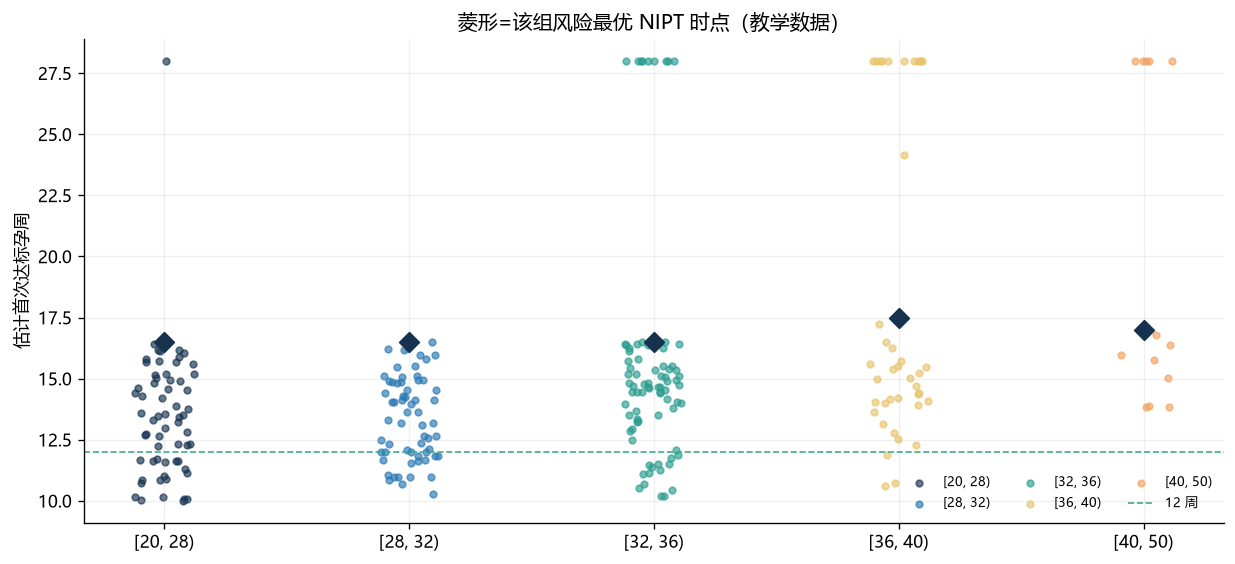

In [10]:
# 问题 2：BMI 分组 + 风险最优时点
# 用每名孕妇的线性外推估计首次达标周，避免“只在已检测点上看”
def first_hit_week(g):
    g = g.sort_values('孕周')
    if g['达标'].max() == 0:
        # 用组外推：浓度对孕周的粗斜率
        if len(g) >= 2:
            sl = LinearRegression().fit(g[['孕周']], g['Y浓度'])
            # 4 = a + b t
            b = sl.coef_[0]
            a = sl.intercept_
            t = (4 - a) / b if b > 1e-6 else 28
        else:
            t = 28
        return np.clip(t, 10, 30)
    return g.loc[g['达标']==1, '孕周'].min()

hit = male.groupby('孕妇').apply(first_hit_week, include_groups=False)
bmi_w = male.groupby('孕妇')['BMI'].mean()
age_w = male.groupby('孕妇')['年龄'].mean()
women = pd.DataFrame({'BMI': bmi_w, '年龄': age_w, '达标周': hit})

# 分组：题面提示可用 [20,28),[28,32),[32,36),[36,40),40+
bins = [20, 28, 32, 36, 40, 50]
women['BMI组'] = pd.cut(women['BMI'], bins=bins, right=False)

def risk_of_week(t):
    # 分段风险：早低、中高、晚极高；再加连续惩罚避免全挤在 12 周
    late = np.where(t <= 12, 1.0, np.where(t <= 27, 3.0 + 0.12 * (t - 12), 8.0 + 0.3 * (t - 27)))
    return late

# 对每组：候选时点 t，失败率用组内 (达标周 > t) 的比例近似
cand = np.linspace(11, 24, 27)
rec = []
best_t = {}
for grp, sub in women.groupby('BMI组', observed=True):
    tw = sub['达标周'].to_numpy()
    scores = []
    for t in cand:
        fail = np.mean(tw > t)
        score = 6.0 * fail + risk_of_week(t)
        scores.append(score)
    tbest = cand[int(np.argmin(scores))]
    best_t[str(grp)] = tbest
    rec.append({
        'BMI组': str(grp), '人数': len(sub),
        '达标周中位数': np.median(tw),
        '最佳时点': tbest,
        '该时点未达标比例': np.mean(tw > tbest),
        '风险得分': np.min(scores)
    })
nipt_grp = pd.DataFrame(rec)

# 检测误差：给 Y 浓度加 ±0.3 再重算最佳时点
women_err = women.copy()
women_err['达标周'] = np.clip(women['达标周'] + rng.normal(0, 0.6, len(women)), 10, 30)
err_shift = []
for grp, sub in women_err.groupby(women['BMI组'], observed=True):
    tw = sub['达标周'].to_numpy()
    scores = [6.0 * np.mean(tw > t) + risk_of_week(t) for t in cand]
    err_shift.append({'BMI组': str(grp), '误差后最佳时点': cand[int(np.argmin(scores))]})
err_tbl = pd.DataFrame(err_shift).merge(nipt_grp[['BMI组','最佳时点']], on='BMI组')

fig, ax = plt.subplots(figsize=(10.4, 4.8))
for i, (grp, sub) in enumerate(women.groupby('BMI组', observed=True)):
    ax.scatter(np.full(len(sub), i) + rng.uniform(-0.12, 0.12, len(sub)),
               sub['达标周'], s=16, alpha=0.65,
               color=list(COLORS.values())[i % 6], label=str(grp))
    ax.scatter(i, best_t[str(grp)], marker='D', s=70, color=COLORS['navy'], zorder=5)
ax.set_xticks(range(len(nipt_grp)))
ax.set_xticklabels(nipt_grp['BMI组'])
ax.axhline(12, color=COLORS['green'], ls='--', lw=1, label='12 周')
ax.set_ylabel('估计首次达标孕周')
ax.set_title('菱形=该组风险最优 NIPT 时点（教学数据）')
ax.legend(frameon=False, ncol=3, fontsize=8)
fig.tight_layout()
print('BMI 越高，达标越晚，最佳时点应后移，但不能拖到中晚期。')
show_result(nipt_grp.round(3))
show_result(err_tbl.round(2), fig)

## 3.3 结果怎么读？

- 相关系数和回归 $p$ 值回答第 1 问：孕周为正、BMI 为负，通常显著。
- 分组后“达标周中位数”只是描述；**最佳时点**综合了失败率和延误风险，所以往往略晚于最早可能达标、又早于中位数。
- 给浓度加噪声后时点若几乎不动，说明分组策略稳健；若高 BMI 组剧烈跳动，论文里要建议这些组重复抽血。

## 3.4 第 3–4 问怎么往下做？

- 第 3 问：把年龄、身高纳入达标周回归，或做混合效应；分组可改成对预测达标周聚类，而不是只切 BMI。
- 第 4 问：女胎用 13/18/21 及 X 的 Z 值、GC 含量做分类，指标看召回率和代价，而不是准确率。
- 多次检测：同一孕妇不独立，应用聚类稳健标准误或混合模型。

## 3.5 正式参赛还应补什么？

- 使用官方附件的真实孕妇队列；
- 孕周字段按 `周+天` 解析；
- 测序失败单独建模；
- 风险函数应用临床依据或层次分析标定，不能只拍 1/3/8；
- 女胎分类要报告混淆矩阵、阈值选择和外部验证。

# 案例四｜2024 美赛 C 题：Momentum in Tennis

> 教练怀疑：球迷嘴里的“势头”会不会只是随机连胜，再叠加“发球本来就容易赢”？题目要你用温网逐分数据，给出能量化、能画图、能预测转折、能推广的模型。下面按小白写论文的顺序，把每一个符号讲清楚。

## 4.1 先用大白话读懂题目

网球一盘由很多局组成，一局由很多分组成。发球的人赢这一分的概率，明显大于接发球的人——这不是动量，这是规则和体能带来的**结构性优势**。

题目给了 2023 温网男单（前两轮之后）每一分：谁发球、谁得分、局分、盘分等。它要你：

1. 建一个能刻画比赛流程的模型：此刻谁更好、好多少，并画出来；
2. 把发球优势考虑进去；
3. 预测势头即将从一方转到另一方的信号，并指出哪些因素最相关；
4. 拿到其他场次上检验，讨论女单、红土、乒乓球能不能用。

最后还要给教练写 1～2 页备忘录，不能只堆公式。

## 4.2 第 1 问怎么写：什么叫“此刻谁更好”

错误做法：连赢 3 分就说有动量。若这 3 分都是自己的发球局，连赢很正常。

正确顺序分三步。

**第一步：估计发球得分率。**

$$
p_{\mathrm{serve}} \;=\; \frac{\text{发球方赢下的分数}}{\text{总分数}}.
$$

正式参赛应按球员、一发/二发、场地分开估。本课先用整场一个数，大约 0.65～0.70。

|符号|人话|
|---|---|
|$p_{\mathrm{serve}}$|“随便抽一分，只要是发球方，他赢的概率”。这是基准，不是动量|

**第二步：这一分是否超出了发球期望。**

$$
e_t \;=\; \mathbf{1}\{\text{第 }t\text{ 分由发球方赢得}\} - p_{\mathrm{serve}}.
$$

|符号|人话|数值直觉|
|---|---|---|
|$t$|从比赛开始数的第几分|1,2,3,…|
|$\mathbf{1}\{\cdot\}$|发球方赢了这一分为 1，否则为 0|
|$e_t$|超额得分。发球方赢了：$e_t\approx 1-0.67=0.33$（只比期望好一点）；接发方赢了（破发）：$e_t\approx 0-0.67=-0.67$（狠狠低于发球期望）|

所以：**保发几乎不推动量，破发狠狠推动量。** 这正是球迷感觉和数学模型对齐的地方。

**第三步：从球员 A 的视角做指数平滑。**

令 $s_t=+1$ 表示这一分是 A 发球，$s_t=-1$ 表示 B 发球。定义

$$
M_t \;=\; \lambda M_{t-1} + (1-\lambda)\, s_t e_t,\qquad M_0=0.
$$

|符号|人话|
|---|---|
|$M_t$|第 $t$ 分结束时，A 的动量。$>0$ 表示 A 比“只靠发球”更好，$<0$ 表示 B 更好，$|M_t|$ 是好多少|
|$\lambda$|记忆参数，本课取 $0.88$。越接近 1，旧势头忘得越慢；越接近 0，只看最近一两分|
|$1-\lambda$|新的超额得分有多听|
|$s_t e_t$|把“发球方超额”翻转到 A 的视角：A 接发得分（破发）会让 $M_t$ 猛增；B 破 A 的发，会让 $M_t$ 猛降|
|$M_0=0$|开场没有历史，双方打平|

这就是第 1 问要的 match flow。论文里画 $M_t$ 对“第几分”的曲线，零线以上 A 更好。局分可以画在下一张图，用来对照“动量领先是否转化成局分领先”。

## 4.3 第 2 问怎么写：预测转折

题目问：有没有信号说明势头马上要换边？

先给“转折”一个可计算的标签，不能只靠肉眼。本课定义：未来 $h=8$ 分内，动量改号，并且幅度够大：

$$
Y_t \;=\; \mathbf{1}\Bigl\{\mathrm{sign}(M_t)\ne\mathrm{sign}(M_{t+h}),\ \lvert M_{t+h}-M_t\rvert > \delta\Bigr\}.
$$

|符号|人话|
|---|---|
|$h$|往前看几分。太短会把噪声当转折，太长教练来不及用。8 分大约是一两局|
|$\mathrm{sign}$|正负号。从正变负或从负变正，才叫换边|
|$\delta$|幅度门槛，本课取 0.04，用来去掉“在 0 附近抖一下”的假转折|
|$Y_t=1$|现在这一分，被我们标成“即将转折”|

特征（决策时都能看见，没有泄漏未来）：

|特征|人话|
|---|---|
|$M_t$|当前动量本身。极大或极小，回归均值的机会也更大|
|近 8 分 A 胜率|最近手感|
|动量斜率 $M_t-M_{t-4}$|势头在加快还是在减速|
|是否进入关键局（例如双方局分都比较高）|破发点、盘点更敏感|

逻辑回归：

$$
\log\frac{P(Y_t=1)}{1-P(Y_t=1)} \;=\; \alpha + w^\top x_t.
$$

|符号|人话|
|---|---|
|$P(Y_t=1)$|模型认为“即将转折”的概率，在 0 和 1 之间|
|左边|对数几率。概率从 0.5 变成 0.7，左边并不是加 0.2，而是非线性地变|
|$\alpha$|截距：特征全为 0 时的基准对数几率|
|$x_t$|上面那组特征拼成的向量|
|$w$|每个特征的权重。例如斜率很负时 $w$ 对应分量若为负，说明“下跌的动量更容易继续跌或更容易反弹”——看数据|

划分：按比赛时间切，前 70% 训练，后 30% 测试，不要把相邻的分打乱。

转折是稀有事件。假设 100 分里只有 15 个转折，傻瓜模型全猜“不转”，准确率已经 85%。所以必须报：

|指标|人话|
|---|---|
|精确率|你报警的那些里，真的转了多少|
|召回率|所有真转折里，你抓住了多少。教练更怕漏报|
|F1|精确率和召回率的调和平均|
|AUC|阈值还没选时，模型把真转折排在假转折前面的能力|

## 4.4 怎样回答“动量是不是幻觉”

把得分序列打乱，但**保留谁在发球**。再算一套假的 $M_t$，看它的一阶自相关

$$
\rho \;=\; \mathrm{Corr}(M_t, M_{t-1}).
$$

重复打乱 200 次，得到 $\rho$ 的空分布。若真实比赛的 $\rho$ 远远落在这个分布右边，说明动量的持续性超过“发球优势 + 随机”，可以反驳教练的怀疑。若落在正中间，论文要诚实写：在这场球里，动量可能只是错觉。

## 4.5 推广和第 4 问备忘录

女单发球优势更弱，$p_{\mathrm{serve}}$ 必须重估。红土破发更多，$e_t$ 的分布会变。乒乓球没有网球这种发球局结构，但“先去掉规则优势，再平滑超额表现”这句骨架可以留。

给教练的备忘录用三句话就够，不要堆 $\lambda$：

1. 动量定义已经去掉发球优势，所以破发比连赢三个发球分更重要；
2. 哪些信号之后转折更常见（例如连续两个破发点没拿下）；
3. 模型在哪些场次失灵（一边倒的碾压局，动量曲线会贴在一侧，转折预测变差）。

In [11]:
def simulate_match(n_points=220, p_serve=0.67, momentum_true=True, seed=7):
    r = np.random.default_rng(seed)
    server = 1  # +1 A 发球, -1 B 发球
    games_a = games_b = 0
    pts_a = pts_b = 0
    M = 0.0
    rows = []
    for t in range(n_points):
        # 真实势头只轻微改变发球得分率
        p = p_serve + (0.06 * M if momentum_true else 0.0)
        p = np.clip(p, 0.52, 0.82)
        serve_wins = r.random() < p
        winner = server if serve_wins else -server
        e = (1.0 if serve_wins else 0.0) - p_serve
        M = 0.88 * M + 0.12 * server * e   # 从 A 视角，破发会反向猛推
        if winner == 1:
            pts_a += 1
        else:
            pts_b += 1
        # 简化：先到 4 分且领先 2 分赢一局；每 2 局换发球
        game_over = (pts_a >= 4 or pts_b >= 4) and abs(pts_a - pts_b) >= 2
        rows.append({
            '分': t + 1, '发球方': 'A' if server == 1 else 'B',
            '得分方': 'A' if winner == 1 else 'B',
            '发球得分': int(serve_wins),
            '动量A': M, 'A局': games_a, 'B局': games_b
        })
        if game_over:
            if pts_a > pts_b:
                games_a += 1
            else:
                games_b += 1
            pts_a = pts_b = 0
            if (games_a + games_b) % 2 == 0:
                server = 1
            else:
                server = -1
        if games_a >= 6 and games_a - games_b >= 2:
            break
        if games_b >= 6 and games_b - games_a >= 2:
            break
    return pd.DataFrame(rows)

match = simulate_match()
p_s = match.groupby('发球方')['发球得分'].mean()
print('比赛长度', len(match), '分；发球得分率：')
print(p_s.round(3).to_string())
show_result(match.head(8))

比赛长度 122 分；发球得分率：
发球方
A    0.667
B    0.755


,分,发球方,得分方,发球得分,动量A,A局,B局
0,1,A,A,1,0.039600,0,0
1,2,A,B,0,-0.045552,0,0
2,3,A,B,0,-0.120486,0,0
3,4,A,A,1,-0.066427,0,0
4,5,A,A,1,-0.018856,0,0
5,6,A,B,0,-0.096993,0,0
6,7,A,A,1,-0.045754,0,0
7,8,A,B,0,-0.120664,0,0


转折是稀有事件，准确率容易虚高，必须看召回率和 AUC。


,准确率,精确率,召回率,F1,AUC,测试集转折比例
0,0.611,0.625,0.312,0.417,0.725,0.444


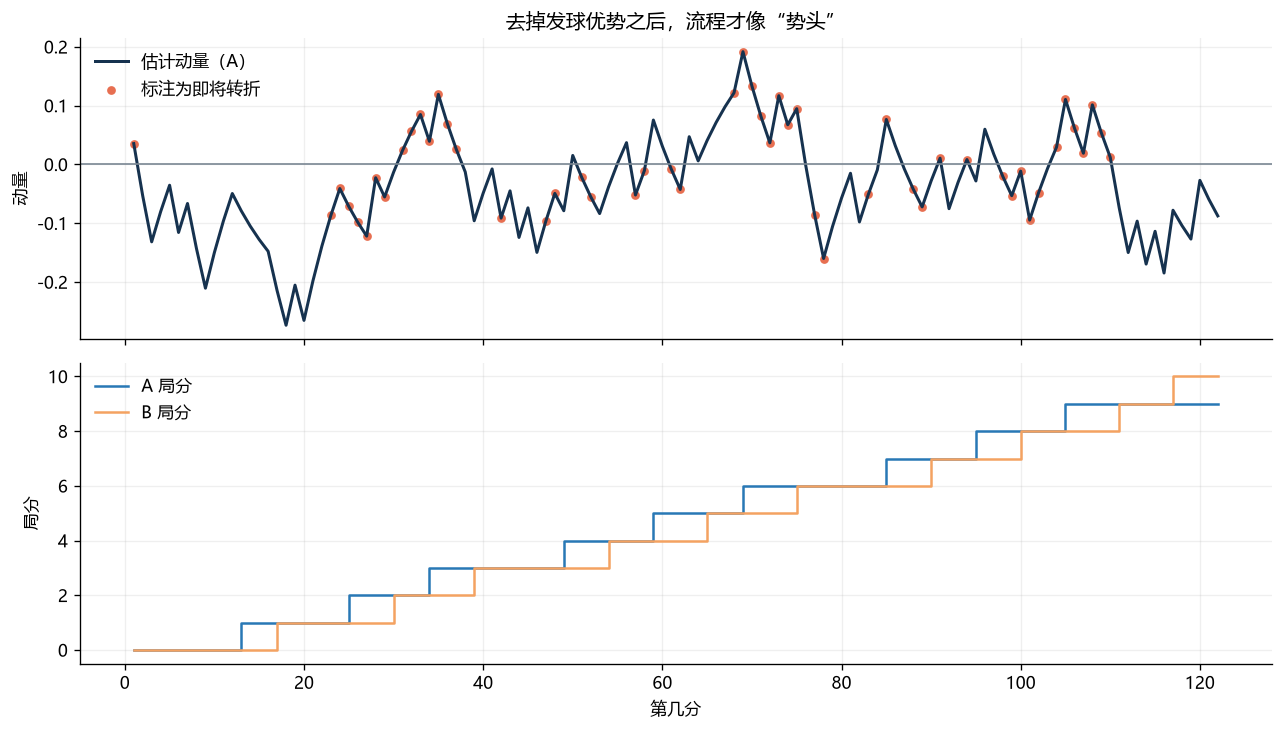

In [12]:
# 复原动量：只用发球指示和谁得分，不偷看模拟器内部的 M
p_serve_hat = match['发球得分'].mean()
e = match['发球得分'] - p_serve_hat
sign = np.where(match['发球方'] == 'A', 1.0, -1.0)
Mhat = np.zeros(len(match))
for i in range(len(match)):
    prev = Mhat[i - 1] if i else 0.0
    Mhat[i] = 0.88 * prev + 0.12 * sign[i] * e.iloc[i]
match['估计动量A'] = Mhat
match['连赢'] = (match['得分方'] == match['得分方'].shift(1)).astype(int)
# 转折标签：未来 8 分动量符号发生变化且幅度跨过阈值
future = pd.Series(Mhat).shift(-8)
swing = ((np.sign(Mhat) != np.sign(future)) & (np.abs(future - Mhat) > 0.04)).astype(int)
swing.iloc[-8:] = 0
match['即将转折'] = swing

# 特征：近 8 分胜率、破发、动量、动量斜率
match['A得分'] = (match['得分方'] == 'A').astype(int)
match['近8分A胜率'] = match['A得分'].rolling(8, min_periods=4).mean()
match['动量斜率'] = pd.Series(Mhat).diff(4)
match['关键分'] = ((match['A局'] + match['B局']) >= 8).astype(int)
feat_m = match.dropna().copy()
Xf = feat_m[['估计动量A','近8分A胜率','动量斜率','关键分']].to_numpy()
yf = feat_m['即将转折'].to_numpy()
cut = int(len(feat_m) * 0.7)
clf = LogisticRegression().fit(Xf[:cut], yf[:cut])
prob = clf.predict_proba(Xf[cut:])[:, 1]
pred = (prob >= 0.5).astype(int)
cls_tbl = pd.DataFrame([{
    '准确率': accuracy_score(yf[cut:], pred),
    '精确率': precision_score(yf[cut:], pred, zero_division=0),
    '召回率': recall_score(yf[cut:], pred, zero_division=0),
    'F1': f1_score(yf[cut:], pred, zero_division=0),
    'AUC': roc_auc_score(yf[cut:], prob) if yf[cut:].std() > 0 else np.nan,
    '测试集转折比例': yf[cut:].mean()
}])

fig, axes = plt.subplots(2, 1, figsize=(10.8, 6.2), sharex=True)
axes[0].plot(match['分'], match['估计动量A'], color=COLORS['navy'], lw=1.8, label='估计动量（A）')
axes[0].axhline(0, color=COLORS['gray'], lw=1)
sw = match.index[match['即将转折'] == 1]
axes[0].scatter(match.loc[sw, '分'], match.loc[sw, '估计动量A'],
                color=COLORS['red'], s=18, label='标注为即将转折')
axes[0].set_ylabel('动量'); axes[0].set_title('去掉发球优势之后，流程才像“势头”')
axes[0].legend(frameon=False)
axes[1].step(match['分'], match['A局'], color=COLORS['blue'], where='post', label='A 局分')
axes[1].step(match['分'], match['B局'], color=COLORS['orange'], where='post', label='B 局分')
axes[1].set_xlabel('第几分'); axes[1].set_ylabel('局分')
axes[1].legend(frameon=False)
fig.tight_layout()
print('转折是稀有事件，准确率容易虚高，必须看召回率和 AUC。')
show_result(cls_tbl.round(3), fig)

## 4.3 怎样回答“动量是不是幻觉”？

做一个对照：把得分序列打乱、但保留发球标记，再算动量的自相关。若真实比赛的动量持续性显著高于打乱后，才能说“不只是随机”。

推广时要换：女单发球优势更弱、红土破发更多、乒乓球回合结构不同。模型骨架可以留，参数必须重估。

## 4.4 正式参赛还应补什么？

- 使用温网官方逐分表，按盘/局/发球局重建；
- 发球得分率按球员、场地、一发/二发分层；
- 用多场比赛做时间外或比赛外验证；
- 给教练的备忘录要写成可执行建议：例如“连续两次破发点失败后，下一局接发增加回到中路”。

# 5. 四道赛题放在一起：预测什么，用什么模型，看什么指标？

|案例|预测对象|正确划分|推荐主模型|必须看的指标|接到的决策|
|---|---|---|---|---|---|
|乙醇|收率 $y_1 y_2$|按实验折|二阶 Ridge 响应面|RMSE、$R^2$、越界率|工艺条件|
|Wordle 人数|未来上报人数|时间切分|趋势+星期+滞后|RMSE、区间覆盖率|容量与内容运营|
|Wordle 分布|(1–6,X)|时间切分|难度平移 / 多项回归|分箱 MAE、KL|题目指定单词|
|NIPT|Y 浓度、达标周|按孕妇分组|OLS / 混合效应|系数 $p$ 值、未达标率|检测时点|
|网球|动量、是否转折|按比赛时间|去发球优势 + 逻辑回归|AUC、召回、校准|临场调整|

## 一句话选择法

- 实验点少、因子有物理范围 → **响应面 / 正则化回归**，不要先上深度网络；
- 每天一条、有季节 → **时序切分 + 滞后特征**，不要随机打乱；
- 同一个人多次观测 → **混合效应或聚类标准误**；
- 题目要区间 → **残差分位 / 分位数回归 / Bootstrap**；
- 类别极不均衡 → **不要只报准确率**。

## 真正通用的能力

$$
\boxed{题意\rightarrow预测合同\rightarrow防泄漏数据\to特征\to基线\to比较\to诊断\to区间\to决策}
$$

# 6. 从 Notebook 到一篇竞赛论文：建议目录

1. **摘要**：预测对象、数据跨度、主模型、关键误差、对决策的建议。
2. **问题重述**：用自己的话写清每一问的输入、输出、时点。
3. **问题分析**：为什么是回归/时序/分类/分布，难点在哪里。
4. **数据预处理**：缺失、异常、口径、泄漏检查。
5. **特征工程**：每个特征的含义和决策时是否可获得。
6. **模型建立**：从基线到主模型，写出方程。
7. **评价与比较**：表格 + 残差图，指标与题目一致。
8. **不确定性**：区间、情景、敏感参数。
9. **结果如何支持决策**。
10. **优点、局限、改进**。
11. **参考文献与可复现代码**。

## “长而细致”不等于堆算法名字

评委更想看到：

- 为什么这个特征在决策时刻看得到；
- 为什么不用随机交叉验证；
- 误差大的那些点有没有共同原因；
- 换一种合理划分，结论还在不在。

# 7. 练习：把课件变成你自己的能力

## 练习 1：乙醇交互项

去掉负载×温度交互后，重新比较 RMSE。若误差明显变差，用残差图说明交互发生在哪一段温度。

## 练习 2：Wordle 区间校准

把 90% 经验区间改成 80% 和 50%，画覆盖率–宽度曲线。讨论：怎样的区间对《纽约时报》更有用。

## 练习 3：NIPT 风险权重

把“测不准”的代价从 6 改成 2 和 12，观察高 BMI 组最佳时点如何移动。这就是第 2 问的敏感性。

## 练习 4：网球对照

把得分序列打乱 200 次，比较真实动量一阶自相关与打乱分布。若真实值落在打乱分布中心，动量可能只是幻觉。

## 练习 5：独立选题

从蔬菜日销量、电池剩余放电时间、空气质量、房价、疫情新增里选一题。必须提交：预测合同表、清洗规则、特征清单、一个基线、一个主模型、一张指标表、一张残差图、三条局限。

# 8. 最后总结

预测类赛题的核心突破，不是会调用 `sklearn`，而是：

1. 先写清预测对象、原点、步长和成功标准；
2. 清洗和特征都要防止泄漏；
3. 划分方式必须匹配数据依赖结构；
4. 先打败朴素基线，再谈复杂模型；
5. 指标要能回到题目语言；
6. 点估计之外还要区间和失败案例；
7. 预测要接到决策，否则只是作业而不是建模。

四个最短记忆：

$$
\boxed{乙醇：小样本响应面，先预测收率再寻优}
$$

$$
\boxed{Wordle：人数看时序，分布看词难度}
$$

$$
\boxed{NIPT：浓度随孕周升、随 BMI 降，时点 = 准 + 早}
$$

$$
\boxed{网球：先去掉发球优势，剩下的才叫动量}
$$

最重要的不是模型名字，而是：**你预测的东西正是题目要的东西，而且在没见过的数据上仍然成立。**